# Cross-Size Paper-Faithful Metrics Blueprint

This notebook is a debugging and verification blueprint for **paper-faithful** behavioral metrics across the size `6`, `12`, and `25` grids.

It focuses on three primary metrics:
- **Transfer**: `transfer_error_diff = mean(first 6 B winter) - mean(last 6 A1 winter)`
- **Retest interference**: `interference = 1 - A_weight_A2` from von Mises fit CSVs
- **Generalisation**: held-out A1 winter test-stimulus accuracy in **late A1**

The notebook is intentionally structured for verification before presentation:
1. explicit cross-size run grid
2. coverage and missingness audit
3. raw `.npz` schema inspection
4. separate helpers for transfer, interference, and generalisation
5. participant-count and mask-diagnostic tables
6. verification figures faceted by size


In [1]:
from pathlib import Path
import os
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

project_root = Path.cwd().resolve()
if project_root.name != "a1b2_modular":
    if (project_root / "a1b2_modular").exists():
        project_root = project_root / "a1b2_modular"
    else:
        for parent in [project_root, *project_root.parents]:
            if parent.name == "a1b2_modular":
                project_root = parent
                break

os.chdir(project_root)

data_root = project_root / "data" / "simulations"
config_path = project_root / "a1b2" / "models" / "experiments.json"
settings = json.loads(config_path.read_text())

size_order = [6, 12, 25]
init_levels = [0.001, 0.01, 0.1, 1.0, 2.0]
condition_order = ["same", "near", "far"]
interference_condition_order = ["near", "far"]
routing_order = ["task_routed", "shared", "single_module"]
sparsity_order = ["no_comms", "0.5", "1.0", "single_module"]
routing_palette = {
    "task_routed": "#4C72B0",
    "shared": "#55A868",
    "single_module": "#C44E52",
}

from a1b2.utils.run_config import build_run_id
from a1b2.analysis.paper_single_baseline import select_single_baseline_df


def sparsity_label_from_condition(c):
    sp = c.get("sparsity", 1.0)
    if sp == 0 or "no_comms" in c.get("name", ""):
        return "no_comms"
    sf = float(sp)
    return "1.0" if np.isclose(sf, 1.0) else str(sf)


def init_scale_from_condition(c):
    init_scale = c.get("init_scale", None)
    return float(1.0 if init_scale is None else init_scale)


def build_cross_size_grid():
    rows = []
    for size in size_order:
        for c in settings["conditions"]:
            if c.get("arch") != "two_module_rnn":
                continue
            if c.get("dim_hidden") != size:
                continue
            if c.get("nb_steps", 1) != 2:
                continue
            if c.get("common_readout", True) is not True:
                continue
            if c.get("common_input", False) is not False:
                continue
            if c.get("init_scope", "global") != "global":
                continue
            sp_label = sparsity_label_from_condition(c)
            init_scale = init_scale_from_condition(c)
            routing = c.get("input_routing", "shared")
            if routing not in ["shared", "task_routed"]:
                continue
            if sp_label not in ["no_comms", "0.5", "1.0"]:
                continue
            if init_scale not in init_levels:
                continue
            run_id = build_run_id(c)
            folder_path = data_root / run_id
            npz_files = sorted(folder_path.glob("sim_*.npz")) if folder_path.exists() else []
            vm_path = data_root / f"{run_id}_vonmises_fits.csv"
            rows.append({
                "size": int(size),
                "routing": routing,
                "sparsity_label": sp_label,
                "init_scale": float(init_scale),
                "comparison_size": int(size),
                "model_dim_hidden": int(c.get("dim_hidden", size)),
                "sim_folder": run_id,
                "folder_path": str(folder_path),
                "path_exists": folder_path.exists(),
                "n_npz": len(npz_files),
                "example_npz": str(npz_files[0]) if npz_files else None,
                "vonmises_path": str(vm_path),
                "vonmises_exists": vm_path.exists(),
            })

        single_df = select_single_baseline_df(
            settings,
            data_root,
            two_module_dim_hidden=size,
            paper_sparsities=["1.0"],
            paper_init_scales=init_levels,
            sparsity_order=["no_comms", "0.5", "1.0", "single_module"],
            build_run_id=build_run_id,
            sparsity_label_from_condition=sparsity_label_from_condition,
            init_scale_from_condition=init_scale_from_condition,
            target_nb_steps=2,
            target_common_readout=True,
            target_common_input=False,
        )
        if not single_df.empty:
            for _, row in single_df.iterrows():
                folder_path = Path(row["path"])
                npz_files = sorted(folder_path.glob("sim_*.npz")) if folder_path.exists() else []
                vm_path = data_root / f"{row['run_id']}_vonmises_fits.csv"
                rows.append({
                    "size": int(size),
                    "routing": "single_module",
                    "sparsity_label": "single_module",
                    "init_scale": float(row["init_scale"]),
                    "comparison_size": int(size),
                    "model_dim_hidden": int(row.get("dim_hidden", size)),
                    "sim_folder": row["run_id"],
                    "folder_path": str(folder_path),
                    "path_exists": folder_path.exists(),
                    "n_npz": len(npz_files),
                    "example_npz": str(npz_files[0]) if npz_files else None,
                    "vonmises_path": str(vm_path),
                    "vonmises_exists": vm_path.exists(),
                })

    grid_df = pd.DataFrame(rows)
    grid_df["size"] = pd.Categorical(grid_df["size"], categories=size_order, ordered=True)
    grid_df["routing"] = pd.Categorical(grid_df["routing"], categories=routing_order, ordered=True)
    grid_df["sparsity_label"] = pd.Categorical(grid_df["sparsity_label"], categories=sparsity_order, ordered=True)
    return grid_df.sort_values(["size", "routing", "sparsity_label", "init_scale", "sim_folder"]).reset_index(drop=True)


grid_df = build_cross_size_grid()

print(f"project_root = {project_root}")
print(f"data_root    = {data_root}")
print(f"grid rows    = {len(grid_df)}")
display(grid_df)

display(
    grid_df.groupby(["size", "routing", "sparsity_label"], observed=True)[["path_exists", "vonmises_exists", "n_npz"]]
    .agg({"path_exists": "sum", "vonmises_exists": "sum", "n_npz": "sum"})
    .reset_index()
)


/home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


project_root = /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular
data_root    = /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations
grid rows    = 105


,size,routing,sparsity_label,init_scale,comparison_size,model_dim_hidden,sim_folder,folder_path,path_exists,n_npz,example_npz,vonmises_path,vonmises_exists
0,6,task_routed,no_comms,0.001,6,6,two_module_rnn_6_task_routed_no_comms_nb2_init...,/home/kat/workspace/Structure-Function-Analysi...,True,206,/home/kat/workspace/Structure-Function-Analysi...,/home/kat/workspace/Structure-Function-Analysi...,False
1,6,task_routed,no_comms,0.010,6,6,two_module_rnn_6_task_routed_no_comms_nb2_init...,/home/kat/workspace/Structure-Function-Analysi...,True,305,/home/kat/workspace/Structure-Function-Analysi...,/home/kat/workspace/Structure-Function-Analysi...,False
2,6,task_routed,no_comms,0.100,6,6,two_module_rnn_6_task_routed_no_comms_nb2_init...,/home/kat/workspace/Structure-Function-Analysi...,True,305,/home/kat/workspace/Structure-Function-Analysi...,/home/kat/workspace/Structure-Function-Analysi...,False
3,6,task_routed,no_comms,1.000,6,6,two_module_rnn_6_task_routed_no_comms_nb2_nb2_...,/home/kat/workspace/Structure-Function-Analysi...,True,305,/home/kat/workspace/Structure-Function-Analysi...,/home/kat/workspace/Structure-Function-Analysi...,False
4,6,task_routed,no_comms,2.000,6,6,two_module_rnn_6_task_routed_no_comms_nb2_init...,/home/kat/workspace/Structure-Function-Analysi...,True,205,/home/kat/workspace/Structure-Function-Analysi...,/home/kat/workspace/Structure-Function-Analysi...,False
5,6,task_routed,0.5,0.001,6,6,two_module_rnn_6_task_routed_sp05_nb2_init0.00...,/home/kat/workspace/Structure-Function-Analysi...,False,0,None,/home/kat/workspace/Structure-Function-Analysi...,False
6,6,task_routed,0.5,0.010,6,6,two_module_rnn_6_task_routed_sp05_nb2_init0.01...,/home/kat/workspace/Structure-Function-Analysi...,True,305,/home/kat/workspace/Structure-Function-Analysi...,/home/kat/workspace/Structure-Function-Analysi...,False
7,6,task_routed,0.5,0.100,6,6,two_module_rnn_6_task_routed_sp05_nb2_init0.1_...,/home/kat/workspace/Structure-Function-Analysi...,True,305,/home/kat/workspace/Structure-Function-Analysi...,/home/kat/workspace/Structure-Function-Analysi...,False
8,6,task_routed,0.5,1.000,6,6,two_module_rnn_6_task_routed_sp05_nb2_nb2_task...,/home/kat/workspace/Structure-Function-Analysi...,True,305,/home/kat/workspace/Structure-Function-Analysi...,/home/kat/workspace/Structure-Function-Analysi...,False
9,6,task_routed,0.5,2.000,6,6,two_module_rnn_6_task_routed_sp05_nb2_init2_nb...,/home/kat/workspace/Structure-Function-Analysi...,False,0,None,/home/kat/workspace/Structure-Function-Analysi...,False


,size,routing,sparsity_label,path_exists,vonmises_exists,n_npz
0,6,task_routed,no_comms,5,0,1326
1,6,task_routed,0.5,3,0,915
2,6,task_routed,1.0,3,0,915
3,6,shared,no_comms,5,0,1308
4,6,shared,0.5,3,0,915
5,6,shared,1.0,3,0,915
6,6,single_module,single_module,3,0,614
7,12,task_routed,no_comms,5,0,1525
8,12,task_routed,0.5,3,0,915
9,12,task_routed,1.0,3,0,915


In [2]:
# Raw schema inspection for representative runs

def inspect_npz_schema(npz_path: Path):
    with np.load(npz_path, allow_pickle=True) as data:
        keys = sorted(data.files)
        rows = []
        for key in ["accuracy", "test_stim", "probes", "indexes", "losses", "predictions"]:
            if key in data:
                arr = np.asarray(data[key])
                rows.append({
                    "key": key,
                    "shape": tuple(arr.shape),
                    "dtype": str(arr.dtype),
                    "nan_count": int(np.isnan(arr).sum()) if np.issubdtype(arr.dtype, np.number) else None,
                })
        return keys, pd.DataFrame(rows)

schema_targets = []
for (_, row) in (
    grid_df[grid_df["path_exists"] & grid_df["example_npz"].notna()]
    .groupby(["size", "routing", "sparsity_label"], observed=True)
    .head(1)
    .iterrows()
):
    schema_targets.append(row)

for row in schema_targets:
    npz_path = Path(row["example_npz"])
    keys, schema_df = inspect_npz_schema(npz_path)
    print(
        f"\nSchema audit: size={row['size']} routing={row['routing']} "
        f"sparsity={row['sparsity_label']} init={row['init_scale']}"
    )
    print(npz_path.name)
    print("keys:", keys)
    display(schema_df)



Schema audit: size=6 routing=task_routed sparsity=no_comms init=0.001
sim_study1_far_sub1.npz
keys: ['accuracy', 'embeddings', 'hiddens', 'hiddens_per_module', 'hiddens_post_phase_0', 'hiddens_post_phase_0_comms_per_module', 'hiddens_post_phase_0_core_per_module', 'hiddens_post_phase_0_per_module', 'hiddens_post_phase_0_trajectory', 'hiddens_post_phase_1', 'hiddens_post_phase_1_comms_per_module', 'hiddens_post_phase_1_core_per_module', 'hiddens_post_phase_1_per_module', 'hiddens_post_phase_1_trajectory', 'hiddens_post_phase_2', 'hiddens_post_phase_2_comms_per_module', 'hiddens_post_phase_2_core_per_module', 'hiddens_post_phase_2_per_module', 'hiddens_post_phase_2_trajectory', 'hiddens_pre_training', 'hiddens_pre_training_per_module', 'hiddens_pre_training_trajectory', 'indexes', 'inputs', 'labels', 'losses', 'predictions', 'preds_post_phase_0', 'preds_post_phase_1', 'preds_post_phase_2', 'preds_pre_training', 'probes', 'readouts', 'test_stim']


,key,shape,dtype,nan_count
0,accuracy,"(3, 12000)",float32,0
1,test_stim,"(3, 12000)",float32,0
2,probes,"(3, 12000)",float32,0
3,indexes,"(3, 12000)",float32,0
4,losses,"(3, 12000)",float32,0
5,predictions,"(3, 12000, 4)",float32,0



Schema audit: size=6 routing=task_routed sparsity=0.5 init=0.01
sim_study1_far_sub1.npz
keys: ['accuracy', 'embeddings', 'hiddens', 'hiddens_per_module', 'hiddens_post_phase_0', 'hiddens_post_phase_0_comms_per_module', 'hiddens_post_phase_0_core_per_module', 'hiddens_post_phase_0_per_module', 'hiddens_post_phase_0_trajectory', 'hiddens_post_phase_1', 'hiddens_post_phase_1_comms_per_module', 'hiddens_post_phase_1_core_per_module', 'hiddens_post_phase_1_per_module', 'hiddens_post_phase_1_trajectory', 'hiddens_post_phase_2', 'hiddens_post_phase_2_comms_per_module', 'hiddens_post_phase_2_core_per_module', 'hiddens_post_phase_2_per_module', 'hiddens_post_phase_2_trajectory', 'hiddens_pre_training', 'hiddens_pre_training_per_module', 'hiddens_pre_training_trajectory', 'indexes', 'inputs', 'labels', 'losses', 'predictions', 'preds_post_phase_0', 'preds_post_phase_1', 'preds_post_phase_2', 'preds_pre_training', 'probes', 'readouts', 'test_stim']


,key,shape,dtype,nan_count
0,accuracy,"(3, 12000)",float32,0
1,test_stim,"(3, 12000)",float32,0
2,probes,"(3, 12000)",float32,0
3,indexes,"(3, 12000)",float32,0
4,losses,"(3, 12000)",float32,0
5,predictions,"(3, 12000, 4)",float32,0



Schema audit: size=6 routing=task_routed sparsity=1.0 init=0.01
sim_study1_far_sub1.npz
keys: ['accuracy', 'embeddings', 'hiddens', 'hiddens_per_module', 'hiddens_post_phase_0', 'hiddens_post_phase_0_comms_per_module', 'hiddens_post_phase_0_core_per_module', 'hiddens_post_phase_0_per_module', 'hiddens_post_phase_0_trajectory', 'hiddens_post_phase_1', 'hiddens_post_phase_1_comms_per_module', 'hiddens_post_phase_1_core_per_module', 'hiddens_post_phase_1_per_module', 'hiddens_post_phase_1_trajectory', 'hiddens_post_phase_2', 'hiddens_post_phase_2_comms_per_module', 'hiddens_post_phase_2_core_per_module', 'hiddens_post_phase_2_per_module', 'hiddens_post_phase_2_trajectory', 'hiddens_pre_training', 'hiddens_pre_training_per_module', 'hiddens_pre_training_trajectory', 'indexes', 'inputs', 'labels', 'losses', 'predictions', 'preds_post_phase_0', 'preds_post_phase_1', 'preds_post_phase_2', 'preds_pre_training', 'probes', 'readouts', 'test_stim']


...

,key,shape,dtype,nan_count
0,accuracy,"(3, 12000)",float32,0
1,test_stim,"(3, 12000)",float32,0
2,probes,"(3, 12000)",float32,0
3,indexes,"(3, 12000)",float32,0
4,losses,"(3, 12000)",float32,0
5,predictions,"(3, 12000, 4)",float32,0



Schema audit: size=25 routing=shared sparsity=1.0 init=0.001
sim_study1_far_sub1.npz
keys: ['accuracy', 'embeddings', 'hiddens', 'hiddens_per_module', 'hiddens_post_phase_0', 'hiddens_post_phase_0_comms_per_module', 'hiddens_post_phase_0_core_per_module', 'hiddens_post_phase_0_per_module', 'hiddens_post_phase_0_trajectory', 'hiddens_post_phase_1', 'hiddens_post_phase_1_comms_per_module', 'hiddens_post_phase_1_core_per_module', 'hiddens_post_phase_1_per_module', 'hiddens_post_phase_1_trajectory', 'hiddens_post_phase_2', 'hiddens_post_phase_2_comms_per_module', 'hiddens_post_phase_2_core_per_module', 'hiddens_post_phase_2_per_module', 'hiddens_post_phase_2_trajectory', 'hiddens_pre_training', 'hiddens_pre_training_per_module', 'hiddens_pre_training_trajectory', 'indexes', 'inputs', 'labels', 'losses', 'predictions', 'preds_post_phase_0', 'preds_post_phase_1', 'preds_post_phase_2', 'preds_pre_training', 'probes', 'readouts', 'test_stim']


,key,shape,dtype,nan_count
0,accuracy,"(3, 12000)",float32,0
1,test_stim,"(3, 12000)",float32,0
2,probes,"(3, 12000)",float32,0
3,indexes,"(3, 12000)",float32,0
4,losses,"(3, 12000)",float32,0
5,predictions,"(3, 12000, 4)",float32,0



Schema audit: size=25 routing=single_module sparsity=single_module init=0.001
sim_study1_far_sub1.npz
keys: ['accuracy', 'embeddings', 'hiddens', 'hiddens_per_module', 'hiddens_post_phase_0', 'hiddens_post_phase_0_comms_per_module', 'hiddens_post_phase_0_core_per_module', 'hiddens_post_phase_0_per_module', 'hiddens_post_phase_0_trajectory', 'hiddens_post_phase_1', 'hiddens_post_phase_1_comms_per_module', 'hiddens_post_phase_1_core_per_module', 'hiddens_post_phase_1_per_module', 'hiddens_post_phase_1_trajectory', 'hiddens_post_phase_2', 'hiddens_post_phase_2_comms_per_module', 'hiddens_post_phase_2_core_per_module', 'hiddens_post_phase_2_per_module', 'hiddens_post_phase_2_trajectory', 'hiddens_pre_training', 'hiddens_pre_training_per_module', 'hiddens_pre_training_trajectory', 'indexes', 'inputs', 'labels', 'losses', 'predictions', 'preds_post_phase_0', 'preds_post_phase_1', 'preds_post_phase_2', 'preds_pre_training', 'probes', 'readouts', 'test_stim']


,key,shape,dtype,nan_count
0,accuracy,"(3, 12000)",float32,0
1,test_stim,"(3, 12000)",float32,0
2,probes,"(3, 12000)",float32,0
3,indexes,"(3, 12000)",float32,0
4,losses,"(3, 12000)",float32,0
5,predictions,"(3, 12000, 4)",float32,0


In [3]:
# Metric helpers based on raw `.npz` contents

REQUIRED_RAW_KEYS = ["accuracy", "probes", "test_stim", "indexes"]


def load_raw_ann_folder(folder: Path, keys=None):
    keys = list(REQUIRED_RAW_KEYS if keys is None else keys)
    condition_data = {"same": [], "near": [], "far": []}
    if not folder.exists():
        return condition_data
    for npz_path in sorted(folder.glob("sim_*.npz")):
        file_name = npz_path.name
        condition = next((cond for cond in condition_data if cond in file_name), None)
        if condition is None:
            continue
        with np.load(npz_path, allow_pickle=True) as data:
            entry = {"participant": npz_path.stem.replace("sim_", "")}
            for key in keys:
                if key in data:
                    entry[key] = data[key]
        condition_data[condition].append(entry)
    return condition_data


def build_raw_ann_cache(grid: pd.DataFrame, keys=None):
    cache = {}
    valid_grid = grid[grid["path_exists"]].copy()
    for _, row in tqdm(valid_grid.iterrows(), total=len(valid_grid), desc="Loading raw cross-size runs"):
        cache[row["sim_folder"]] = load_raw_ann_folder(Path(row["folder_path"]), keys=keys)
    return cache


def compute_transfer_df_from_cache(grid: pd.DataFrame, raw_cache: dict):
    rows = []
    valid_grid = grid[grid["path_exists"]].copy()
    for _, row in tqdm(valid_grid.iterrows(), total=len(valid_grid), desc="Computing transfer"):
        ann_data = raw_cache.get(row["sim_folder"], {"same": [], "near": [], "far": []})
        for condition, entries in ann_data.items():
            for entry in entries:
                if "accuracy" not in entry:
                    continue
                acc = np.asarray(entry["accuracy"])
                if acc.ndim < 2 or acc.shape[0] < 2:
                    continue
                a1_winter = acc[0, 1::2].astype(float)
                b_winter = acc[1, 1::2].astype(float)
                if len(a1_winter) < 6 or len(b_winter) < 6:
                    continue
                rows.append({
                    "size": int(row["size"]),
                    "routing": row["routing"],
                    "sparsity_label": row["sparsity_label"],
                    "init_scale": float(row["init_scale"]),
                    "sim_folder": row["sim_folder"],
                    "participant": entry["participant"],
                    "condition": condition,
                    "transfer_error_diff": float(np.nanmean(b_winter[:6]) - np.nanmean(a1_winter[-6:])),
                })
    return pd.DataFrame(rows)


def compute_generalisation_df_from_cache(grid: pd.DataFrame, raw_cache: dict):
    rows = []
    valid_grid = grid[grid["path_exists"]].copy()
    for _, row in tqdm(valid_grid.iterrows(), total=len(valid_grid), desc="Computing generalisation"):
        ann_data = raw_cache.get(row["sim_folder"], {"same": [], "near": [], "far": []})
        for condition, entries in ann_data.items():
            for entry in entries:
                required = {"accuracy", "probes", "test_stim", "indexes"}
                if not required.issubset(entry):
                    rows.append({
                        "size": int(row["size"]),
                        "routing": row["routing"],
                        "sparsity_label": row["sparsity_label"],
                        "init_scale": float(row["init_scale"]),
                        "sim_folder": row["sim_folder"],
                        "participant": entry["participant"],
                        "condition": condition,
                        "generalisation_paper_faithful": np.nan,
                        "generalisation_holton_ann_style": np.nan,
                        "n_generalisation_trials_paper": 0,
                        "n_generalisation_trials_holton": 0,
                        "n_phase_a1": np.nan,
                        "n_probe_winter": np.nan,
                        "n_test_stim": np.nan,
                        "n_late_block": np.nan,
                        "missing_required_keys": True,
                    })
                    continue
                acc = np.asarray(entry["accuracy"])
                probes = np.asarray(entry["probes"])
                test_stim = np.asarray(entry["test_stim"])
                indexes = np.asarray(entry["indexes"])
                if acc.ndim < 2:
                    continue
                a1_acc = acc[0].astype(float)
                a1_probe = probes[0].astype(float)
                a1_test = test_stim[0].astype(float)
                a1_idx = indexes[0].astype(float)
                valid = np.isfinite(a1_acc) & np.isfinite(a1_probe) & np.isfinite(a1_test) & np.isfinite(a1_idx)
                winter_mask = a1_probe == 1
                test_mask = a1_test == 1
                holton_mask = valid & winter_mask & test_mask
                trial_pos = np.arange(len(a1_acc), dtype=int)
                block_in_schedule = (trial_pos // 12) % 10
                late_mask = block_in_schedule >= 5
                paper_mask = holton_mask & late_mask
                rows.append({
                    "size": int(row["size"]),
                    "routing": row["routing"],
                    "sparsity_label": row["sparsity_label"],
                    "init_scale": float(row["init_scale"]),
                    "sim_folder": row["sim_folder"],
                    "participant": entry["participant"],
                    "condition": condition,
                    "generalisation_paper_faithful": float(np.nanmean(a1_acc[paper_mask])) if np.any(paper_mask) else np.nan,
                    "generalisation_holton_ann_style": float(np.nanmean(a1_acc[holton_mask])) if np.any(holton_mask) else np.nan,
                    "n_generalisation_trials_paper": int(np.sum(paper_mask)),
                    "n_generalisation_trials_holton": int(np.sum(holton_mask)),
                    "n_phase_a1": int(np.sum(valid)),
                    "n_probe_winter": int(np.sum(valid & winter_mask)),
                    "n_test_stim": int(np.sum(valid & test_mask)),
                    "n_late_block": int(np.sum(valid & late_mask)),
                    "missing_required_keys": False,
                })
    return pd.DataFrame(rows)


def compute_secondary_ann_metrics_from_cache(grid: pd.DataFrame, raw_cache: dict):
    rows = []
    valid_grid = grid[grid["path_exists"]].copy()
    for _, row in tqdm(valid_grid.iterrows(), total=len(valid_grid), desc="Computing secondary ANN metrics"):
        ann_data = raw_cache.get(row["sim_folder"], {"same": [], "near": [], "far": []})
        for condition, entries in ann_data.items():
            for entry in entries:
                if "accuracy" not in entry:
                    continue
                acc = np.asarray(entry["accuracy"])
                if acc.ndim < 2 or acc.shape[0] < 3:
                    continue
                a1_winter = acc[0, 1::2].astype(float)
                b_winter = acc[1, 1::2].astype(float)
                a2_winter = acc[2, 1::2].astype(float)
                a1_summer = acc[0, 0::2].astype(float)
                if len(a1_winter) < 6 or len(b_winter) < 6 or len(a2_winter) == 0 or len(a1_summer) == 0:
                    continue
                final_a1 = float(np.nanmean(a1_winter[-6:]))
                initial_b = float(np.nanmean(b_winter[:6]))
                a2_mean = float(np.nanmean(a2_winter))
                summer_task_a_scoped = float(np.nanmean(a1_summer))
                summer_holton_ann_style = float(np.nanmean(a1_summer))
                rows.append({
                    "size": int(row["size"]),
                    "routing": row["routing"],
                    "sparsity_label": row["sparsity_label"],
                    "init_scale": float(row["init_scale"]),
                    "sim_folder": row["sim_folder"],
                    "participant": entry["participant"],
                    "condition": condition,
                    "summer_accuracy_taskA_scoped": summer_task_a_scoped,
                    "summer_accuracy_holton_ann_style": summer_holton_ann_style,
                    "retest_error_diff": a2_mean - final_a1,
                    "transfer_error_diff_recomputed": initial_b - final_a1,
                })
    return pd.DataFrame(rows)


def load_human_afc_df(project_root: Path):
    trial_df = pd.read_csv(project_root / "data" / "participants" / "trial_df.csv")
    afc_df = (
        trial_df[trial_df["task_section"] == "debrief"]
        .groupby("participant", as_index=False)["correct_afc"]
        .mean()
    )
    afc_df["correct_afc"] = 100.0 * afc_df["correct_afc"].astype(float)
    return afc_df


def load_interference_df(grid: pd.DataFrame):
    rows = []
    valid_grid = grid[grid["vonmises_exists"]].copy()
    for _, row in tqdm(valid_grid.iterrows(), total=len(valid_grid), desc="Loading von Mises fits"):
        fit_df = pd.read_csv(row["vonmises_path"]).copy()
        required = {"participant", "condition", "A_weight_A2"}
        if not required.issubset(fit_df.columns):
            continue
        fit_df = fit_df[fit_df["condition"].isin(interference_condition_order)].copy()
        if fit_df.empty:
            continue
        fit_df["size"] = int(row["size"])
        fit_df["routing"] = row["routing"]
        fit_df["sparsity_label"] = row["sparsity_label"]
        fit_df["init_scale"] = float(row["init_scale"])
        fit_df["sim_folder"] = row["sim_folder"]
        fit_df["interference"] = 1.0 - fit_df["A_weight_A2"].astype(float)
        rows.append(fit_df[["participant", "condition", "size", "routing", "sparsity_label", "init_scale", "sim_folder", "A_weight_A2", "interference"]])
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


In [4]:
# Step 1: load only the raw arrays needed for transfer/generalisation once

RAW_KEYS_FOR_METRICS = ["accuracy", "probes", "test_stim", "indexes"]
raw_ann_cache = build_raw_ann_cache(grid_df, keys=RAW_KEYS_FOR_METRICS)
print("cached raw runs:", len(raw_ann_cache))


Loading raw cross-size runs: 100%|██████████| 87/87 [00:56<00:00,  1.55it/s]

cached raw runs: 87


In [5]:
# Step 2: compute transfer from cached raw arrays

transfer_df = compute_transfer_df_from_cache(grid_df, raw_ann_cache)
print("transfer_df:", transfer_df.shape)
transfer_df.head()


Computing transfer: 100%|██████████| 87/87 [00:02<00:00, 43.41it/s]

transfer_df: (25644, 8)


,size,routing,sparsity_label,init_scale,sim_folder,participant,condition,transfer_error_diff
0,6,task_routed,no_comms,0.001,two_module_rnn_6_task_routed_no_comms_nb2_init...,study1_same_sub12,same,-0.449223
1,6,task_routed,no_comms,0.001,two_module_rnn_6_task_routed_no_comms_nb2_init...,study1_same_sub13,same,-0.305724
2,6,task_routed,no_comms,0.001,two_module_rnn_6_task_routed_no_comms_nb2_init...,study1_same_sub15,same,-0.437950
3,6,task_routed,no_comms,0.001,two_module_rnn_6_task_routed_no_comms_nb2_init...,study1_same_sub16,same,-0.347986
4,6,task_routed,no_comms,0.001,two_module_rnn_6_task_routed_no_comms_nb2_init...,study1_same_sub17,same,-0.355917


In [6]:
# Step 3: compute both generalisation variants from cached raw arrays

generalisation_df = compute_generalisation_df_from_cache(grid_df, raw_ann_cache)
print("generalisation_df:", generalisation_df.shape)
generalisation_df.head()


Computing generalisation: 100%|██████████| 87/87 [00:06<00:00, 13.59it/s]

generalisation_df: (25644, 16)


,size,routing,sparsity_label,init_scale,sim_folder,participant,condition,generalisation_paper_faithful,generalisation_holton_ann_style,n_generalisation_trials_paper,n_generalisation_trials_holton,n_phase_a1,n_probe_winter,n_test_stim,n_late_block,missing_required_keys
0,6,task_routed,no_comms,0.001,two_module_rnn_6_task_routed_no_comms_nb2_init...,study1_same_sub12,same,0.505300,0.504653,500,1000,12000,6000,1000,6000,False
1,6,task_routed,no_comms,0.001,two_module_rnn_6_task_routed_no_comms_nb2_init...,study1_same_sub13,same,0.015894,0.018477,500,1000,12000,6000,1000,6000,False
2,6,task_routed,no_comms,0.001,two_module_rnn_6_task_routed_no_comms_nb2_init...,study1_same_sub15,same,0.211720,0.211018,500,1000,12000,6000,1000,6000,False
3,6,task_routed,no_comms,0.001,two_module_rnn_6_task_routed_no_comms_nb2_init...,study1_same_sub16,same,0.145646,0.146556,500,1000,12000,6000,1000,6000,False
4,6,task_routed,no_comms,0.001,two_module_rnn_6_task_routed_no_comms_nb2_init...,study1_same_sub17,same,0.196613,0.197195,500,1000,12000,6000,1000,6000,False


In [7]:
# Step 4: load paper-faithful interference from von Mises fit CSVs

interference_df = load_interference_df(grid_df)
print("interference_df:", interference_df.shape)
interference_df.head()


Loading von Mises fits: 100%|██████████| 38/38 [00:00<00:00, 334.76it/s]

interference_df: (7599, 9)


,participant,condition,size,routing,sparsity_label,init_scale,sim_folder,A_weight_A2,interference
0,sim_study2_near_sub38,near,12,single_module,single_module,0.001,single_module_rnn_25_nb2_init0.001_nb2_shared_...,0.000002,0.999998
1,sim_study1_near_sub50,near,12,single_module,single_module,0.001,single_module_rnn_25_nb2_init0.001_nb2_shared_...,0.000006,0.999994
2,sim_study2_near_sub66,near,12,single_module,single_module,0.001,single_module_rnn_25_nb2_init0.001_nb2_shared_...,0.000029,0.999971
3,sim_study1_near_sub47,near,12,single_module,single_module,0.001,single_module_rnn_25_nb2_init0.001_nb2_shared_...,0.000014,0.999986
4,sim_study2_near_sub30,near,12,single_module,single_module,0.001,single_module_rnn_25_nb2_init0.001_nb2_shared_...,0.000003,0.999997


In [8]:
# Step 5: compute additional ANN metrics and load human AFC

secondary_ann_df = compute_secondary_ann_metrics_from_cache(grid_df, raw_ann_cache)
human_afc_df = load_human_afc_df(project_root)

print("secondary_ann_df:", secondary_ann_df.shape)
print("human_afc_df:", human_afc_df.shape)
display(secondary_ann_df.head())
display(human_afc_df.head())


Computing secondary ANN metrics: 100%|██████████| 87/87 [00:04<00:00, 21.04it/s]


secondary_ann_df: (25644, 11)
human_afc_df: (305, 2)


,size,routing,sparsity_label,init_scale,sim_folder,participant,condition,summer_accuracy_taskA_scoped,summer_accuracy_holton_ann_style,retest_error_diff,transfer_error_diff_recomputed
0,6,task_routed,no_comms,0.001,two_module_rnn_6_task_routed_no_comms_nb2_init...,study1_same_sub12,same,0.850025,0.850025,0.052379,-0.449223
1,6,task_routed,no_comms,0.001,two_module_rnn_6_task_routed_no_comms_nb2_init...,study1_same_sub13,same,0.845934,0.845934,0.002848,-0.305724
2,6,task_routed,no_comms,0.001,two_module_rnn_6_task_routed_no_comms_nb2_init...,study1_same_sub15,same,0.849226,0.849226,0.015947,-0.437950
3,6,task_routed,no_comms,0.001,two_module_rnn_6_task_routed_no_comms_nb2_init...,study1_same_sub16,same,0.847325,0.847325,-0.056094,-0.347986
4,6,task_routed,no_comms,0.001,two_module_rnn_6_task_routed_no_comms_nb2_init...,study1_same_sub17,same,0.848651,0.848651,-0.005020,-0.355917


,participant,correct_afc
0,study1_far_sub1,100.000000
1,study1_far_sub10,70.833333
2,study1_far_sub12,75.000000
3,study1_far_sub13,95.833333
4,study1_far_sub15,87.500000


In [9]:
# Debugging tables: coverage, participant counts, and metric diagnostics

display(
    grid_df[
        [
            "size", "routing", "sparsity_label", "init_scale", "path_exists", "n_npz",
            "vonmises_exists", "sim_folder"
        ]
    ]
    .sort_values(["size", "routing", "sparsity_label", "init_scale"])
    .reset_index(drop=True)
)

if not transfer_df.empty:
    display(
        transfer_df.groupby(["size", "routing", "sparsity_label", "init_scale", "condition"], observed=True)
        .agg(n_participants=("participant", "nunique"), mean_transfer=("transfer_error_diff", "mean"))
        .reset_index()
        .sort_values(["size", "routing", "sparsity_label", "init_scale", "condition"])
    )
else:
    print("Transfer dataframe is empty.")

if not interference_df.empty:
    display(
        interference_df.groupby(["size", "routing", "sparsity_label", "init_scale", "condition"], observed=True)
        .agg(
            n_participants=("participant", "nunique"),
            mean_A_weight_A2=("A_weight_A2", "mean"),
            mean_interference=("interference", "mean"),
        )
        .reset_index()
        .sort_values(["size", "routing", "sparsity_label", "init_scale", "condition"])
    )
else:
    print("Interference dataframe is empty.")

if not generalisation_df.empty:
    display(
        generalisation_df.groupby(["size", "routing", "sparsity_label", "init_scale", "condition"], observed=True)
        .agg(
            n_participants=("participant", "nunique"),
            mean_generalisation_paper=("generalisation_paper_faithful", "mean"),
            mean_generalisation_holton=("generalisation_holton_ann_style", "mean"),
            mean_trials_paper=("n_generalisation_trials_paper", "mean"),
            mean_trials_holton=("n_generalisation_trials_holton", "mean"),
            missing_required_keys=("missing_required_keys", "sum"),
        )
        .reset_index()
        .sort_values(["size", "routing", "sparsity_label", "init_scale", "condition"])
    )
else:
    print("Generalisation dataframe is empty.")

if not secondary_ann_df.empty:
    display(
        secondary_ann_df.groupby(["size", "routing", "sparsity_label", "init_scale", "condition"], observed=True)
        .agg(
            n_participants=("participant", "nunique"),
            mean_summer_taskA=("summer_accuracy_taskA_scoped", "mean"),
            mean_summer_holton=("summer_accuracy_holton_ann_style", "mean"),
            mean_retest_error_diff=("retest_error_diff", "mean"),
        )
        .reset_index()
        .sort_values(["size", "routing", "sparsity_label", "init_scale", "condition"])
    )
else:
    print("Secondary ANN metric dataframe is empty.")

if not human_afc_df.empty:
    display(pd.DataFrame({
        "n_participants": [human_afc_df["participant"].nunique()],
        "mean_correct_afc": [human_afc_df["correct_afc"].mean()],
        "sem_correct_afc": [human_afc_df["correct_afc"].sem()],
        "min_correct_afc": [human_afc_df["correct_afc"].min()],
        "max_correct_afc": [human_afc_df["correct_afc"].max()],
    }))
else:
    print("Human AFC dataframe is empty.")


,size,routing,sparsity_label,init_scale,path_exists,n_npz,vonmises_exists,sim_folder
0,6,task_routed,no_comms,0.001,True,206,False,two_module_rnn_6_task_routed_no_comms_nb2_init...
1,6,task_routed,no_comms,0.010,True,305,False,two_module_rnn_6_task_routed_no_comms_nb2_init...
2,6,task_routed,no_comms,0.100,True,305,False,two_module_rnn_6_task_routed_no_comms_nb2_init...
3,6,task_routed,no_comms,1.000,True,305,False,two_module_rnn_6_task_routed_no_comms_nb2_nb2_...
4,6,task_routed,no_comms,2.000,True,205,False,two_module_rnn_6_task_routed_no_comms_nb2_init...
5,6,task_routed,0.5,0.001,False,0,False,two_module_rnn_6_task_routed_sp05_nb2_init0.00...
6,6,task_routed,0.5,0.010,True,305,False,two_module_rnn_6_task_routed_sp05_nb2_init0.01...
7,6,task_routed,0.5,0.100,True,305,False,two_module_rnn_6_task_routed_sp05_nb2_init0.1_...
8,6,task_routed,0.5,1.000,True,305,False,two_module_rnn_6_task_routed_sp05_nb2_nb2_task...
9,6,task_routed,0.5,2.000,False,0,False,two_module_rnn_6_task_routed_sp05_nb2_init2_nb...


,size,routing,sparsity_label,init_scale,condition,n_participants,mean_transfer
0,6,shared,0.5,0.01,far,101,-0.610826
1,6,shared,0.5,0.01,near,101,-0.468815
2,6,shared,0.5,0.01,same,103,-0.453238
3,6,shared,0.5,0.10,far,101,-0.608811
4,6,shared,0.5,0.10,near,101,-0.470882
...,...,...,...,...,...,...,...
256,25,task_routed,no_comms,1.00,near,101,-0.398331
257,25,task_routed,no_comms,1.00,same,103,-0.397361
258,25,task_routed,no_comms,2.00,far,101,-0.402362
259,25,task_routed,no_comms,2.00,near,101,-0.411590


,size,routing,sparsity_label,init_scale,condition,n_participants,mean_A_weight_A2,mean_interference
0,12,single_module,single_module,0.001,far,101,0.481173,5.188268e-01
1,12,single_module,single_module,0.001,near,101,0.000017,9.999831e-01
2,12,single_module,single_module,1.000,far,101,0.933905,6.609464e-02
3,12,single_module,single_module,1.000,near,101,0.802213,1.977872e-01
4,12,single_module,single_module,2.000,far,101,0.905183,9.481662e-02
5,12,single_module,single_module,2.000,near,101,0.771319,2.286809e-01
6,25,shared,0.5,0.001,far,101,0.748070,2.519304e-01
7,25,shared,0.5,0.001,near,101,0.000264,9.997361e-01
8,25,shared,0.5,0.010,far,101,1.000000,5.716000e-17
9,25,shared,0.5,0.010,near,101,0.000261,9.997393e-01


,size,routing,sparsity_label,init_scale,condition,n_participants,mean_generalisation_paper,mean_generalisation_holton,mean_trials_paper,mean_trials_holton,missing_required_keys
0,6,shared,0.5,0.01,far,101,0.828180,0.826140,500.0,1000.0,0
1,6,shared,0.5,0.01,near,101,0.826425,0.824365,500.0,1000.0,0
2,6,shared,0.5,0.01,same,103,0.828280,0.826394,500.0,1000.0,0
3,6,shared,0.5,0.10,far,101,0.893782,0.891999,500.0,1000.0,0
4,6,shared,0.5,0.10,near,101,0.892288,0.890529,500.0,1000.0,0
...,...,...,...,...,...,...,...,...,...,...,...
256,25,task_routed,no_comms,1.00,near,101,0.316721,0.317164,500.0,1000.0,0
257,25,task_routed,no_comms,1.00,same,103,0.348911,0.349317,500.0,1000.0,0
258,25,task_routed,no_comms,2.00,far,101,0.464525,0.464527,500.0,1000.0,0
259,25,task_routed,no_comms,2.00,near,101,0.460363,0.460468,500.0,1000.0,0


,size,routing,sparsity_label,init_scale,condition,n_participants,mean_summer_taskA,mean_summer_holton,mean_retest_error_diff
0,6,shared,0.5,0.01,far,101,0.917664,0.917664,-0.059223
1,6,shared,0.5,0.01,near,101,0.918241,0.918241,-0.121657
2,6,shared,0.5,0.01,same,103,0.917821,0.917821,-0.014840
3,6,shared,0.5,0.10,far,101,0.955636,0.955636,-0.029176
4,6,shared,0.5,0.10,near,101,0.955707,0.955707,-0.119204
...,...,...,...,...,...,...,...,...,...
256,25,task_routed,no_comms,1.00,near,101,0.991222,0.991222,-0.009684
257,25,task_routed,no_comms,1.00,same,103,0.991309,0.991309,-0.015432
258,25,task_routed,no_comms,2.00,far,101,0.997075,0.997075,-0.134188
259,25,task_routed,no_comms,2.00,near,101,0.996965,0.996965,-0.137108


,n_participants,mean_correct_afc,sem_correct_afc,min_correct_afc,max_correct_afc
0,305,81.92623,1.207129,0.0,100.0


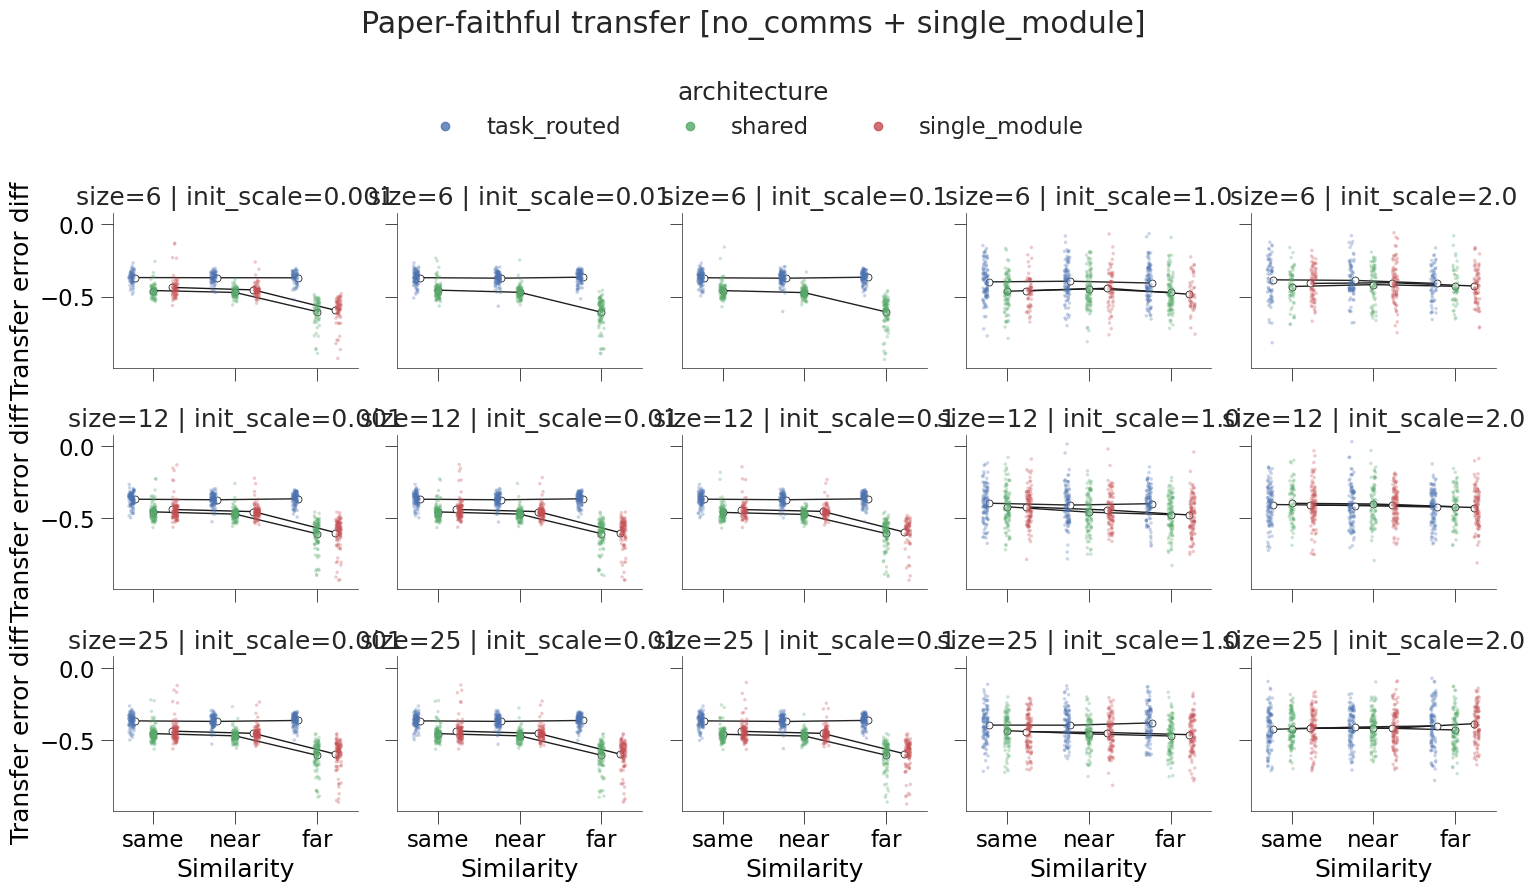

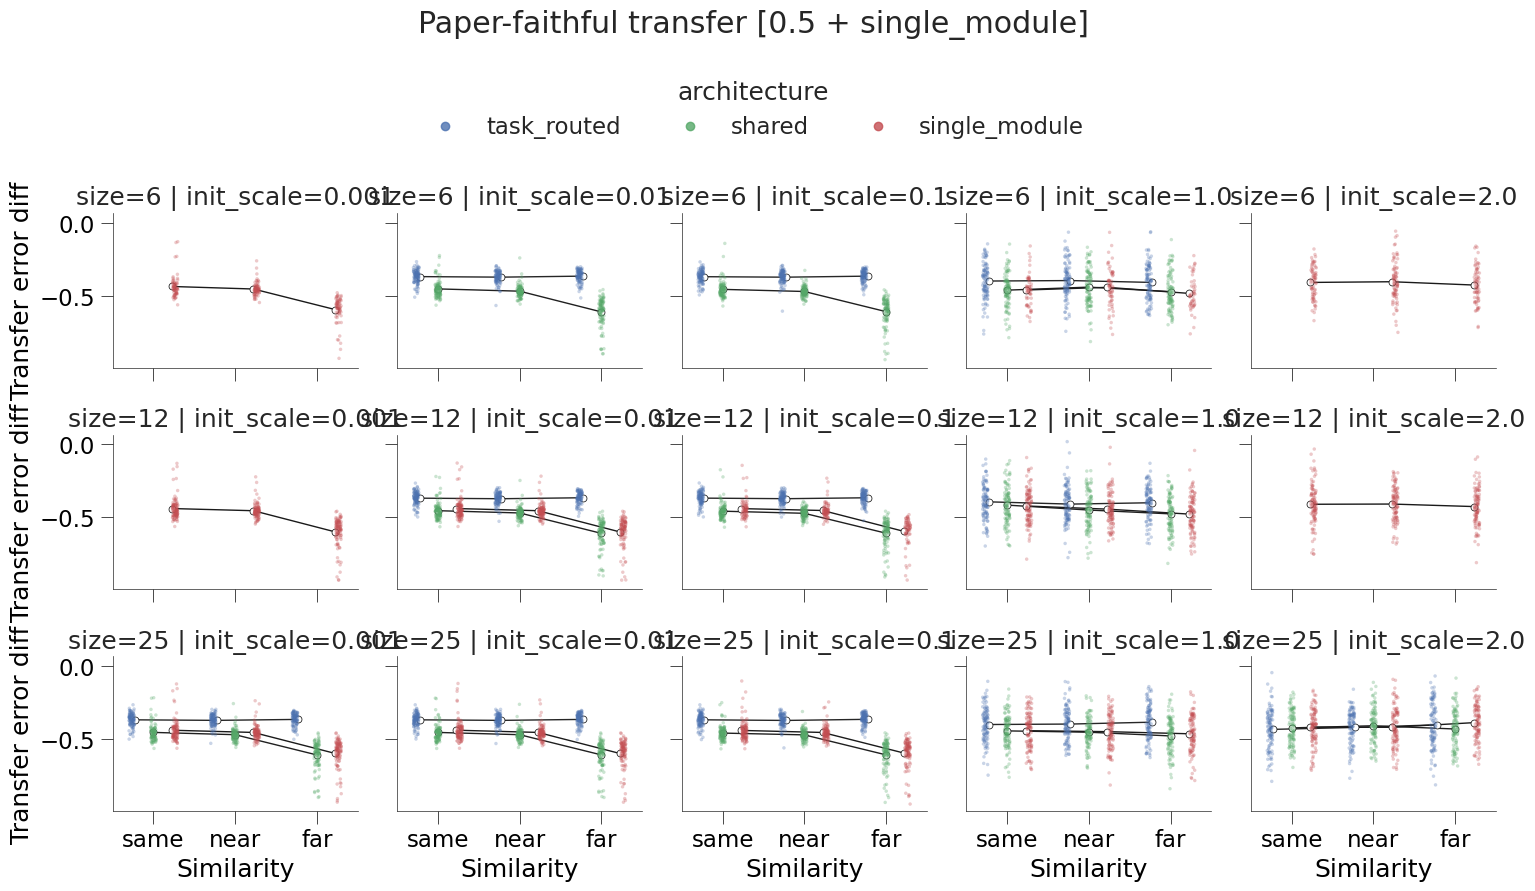

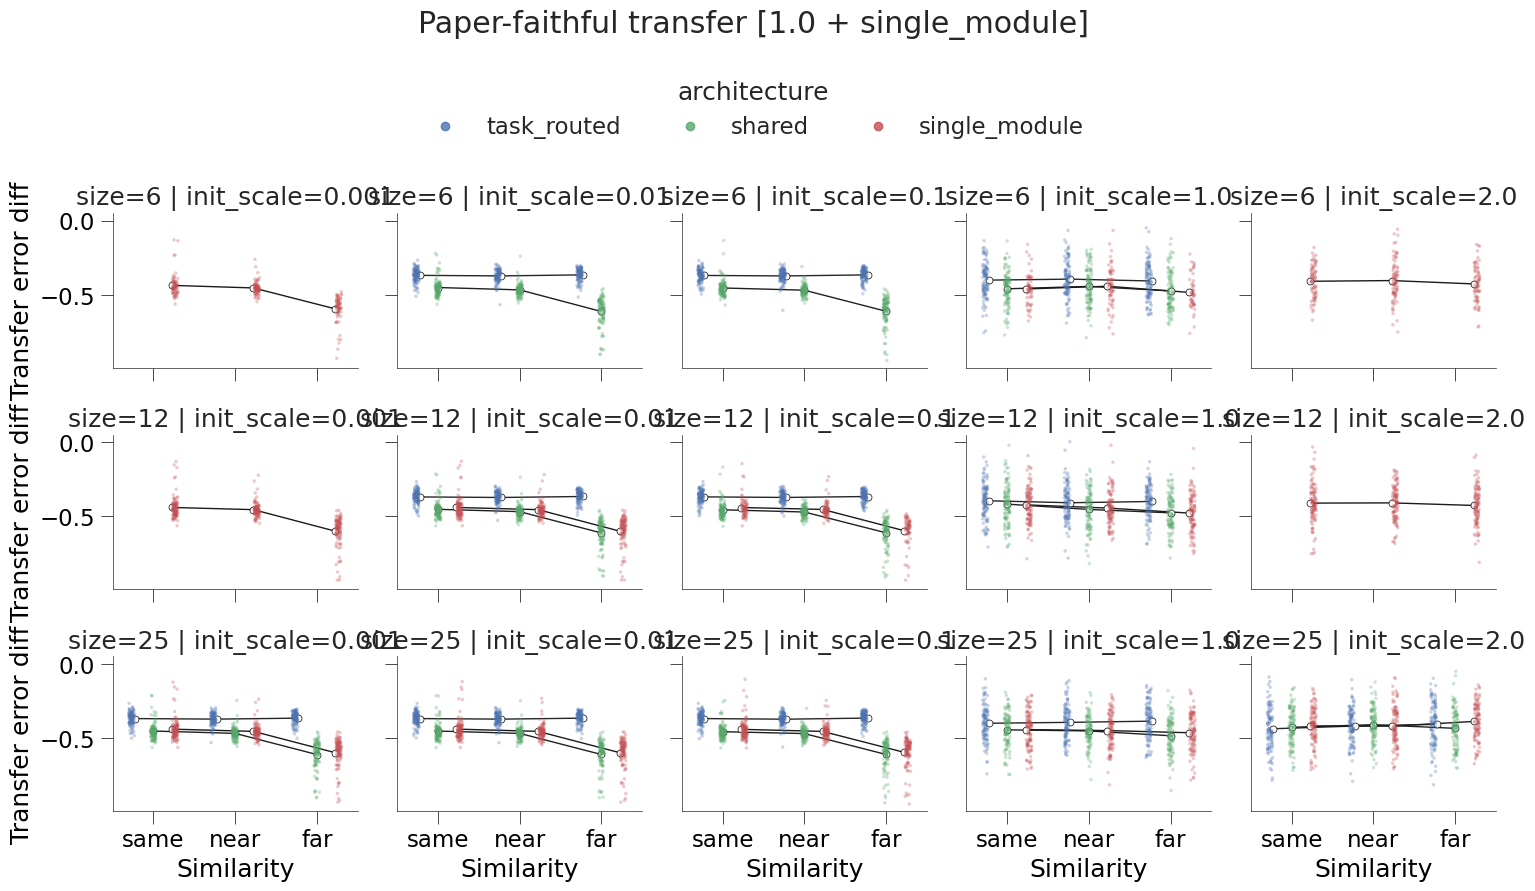

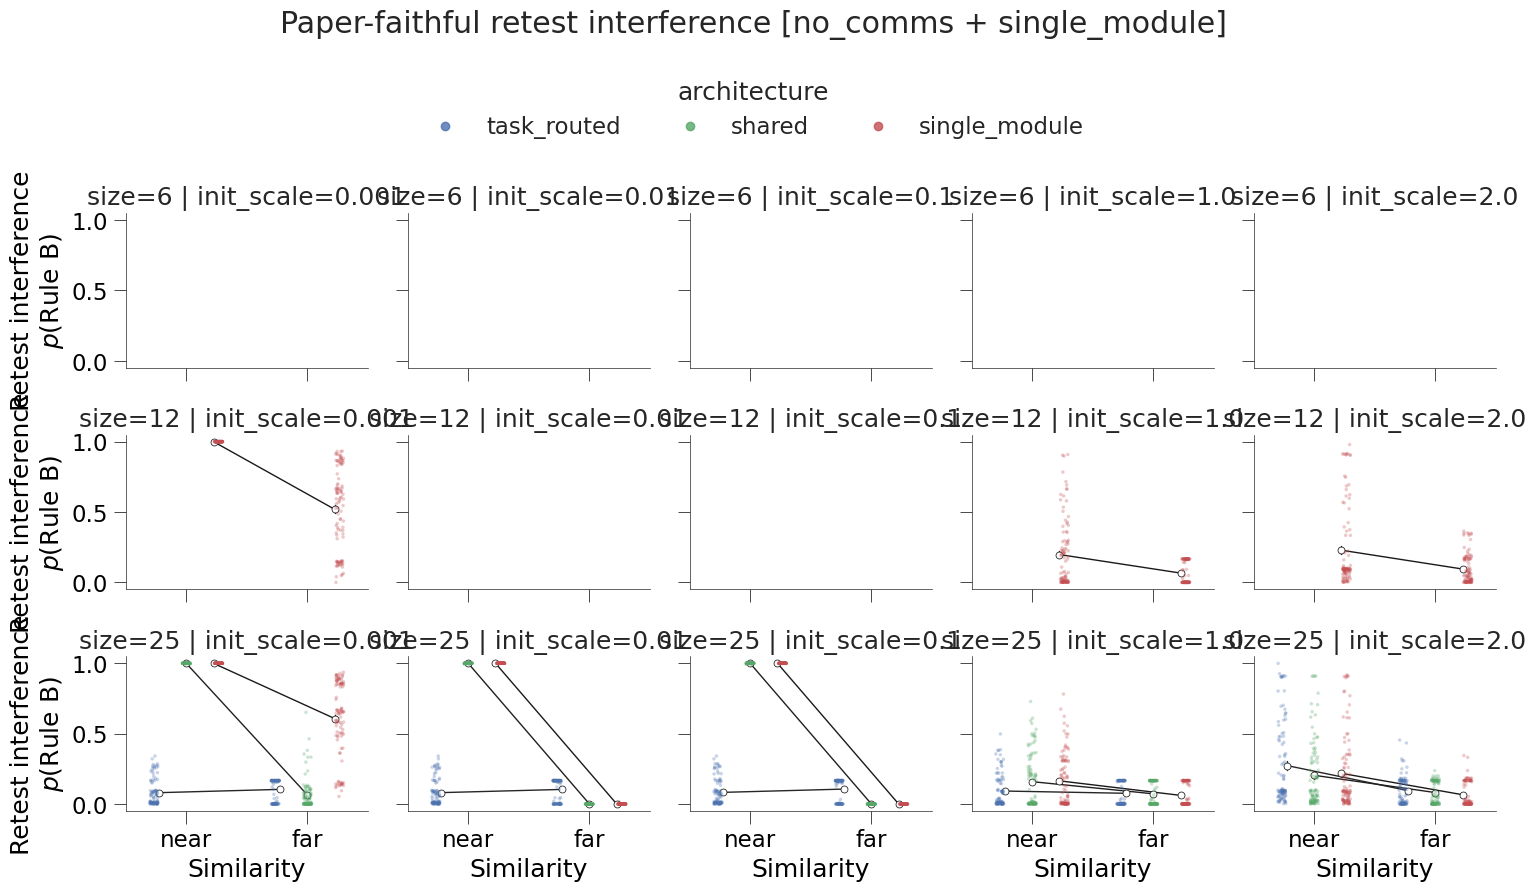

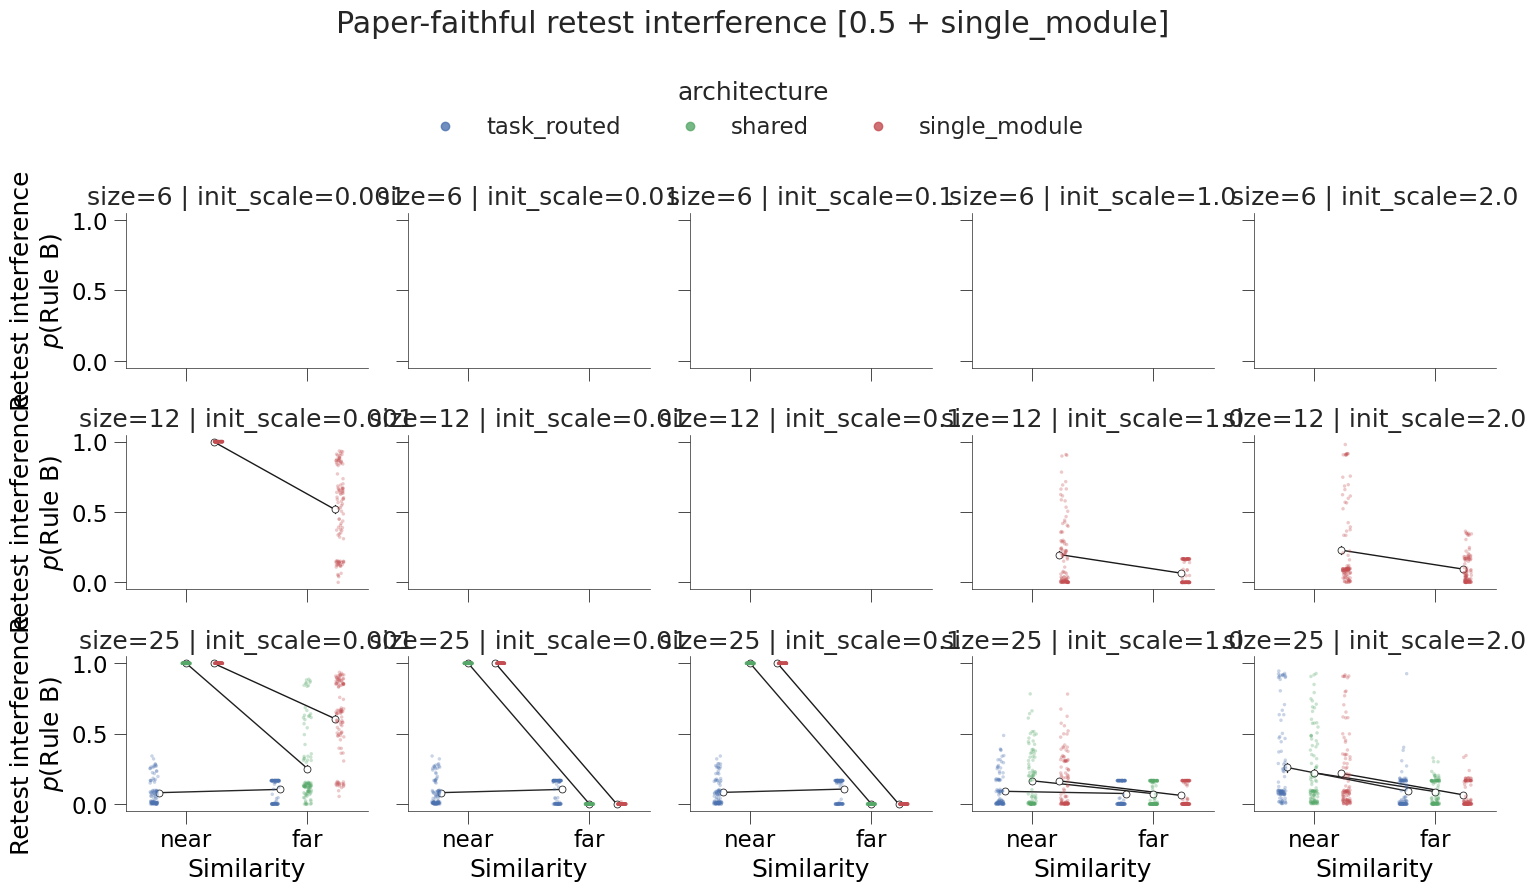

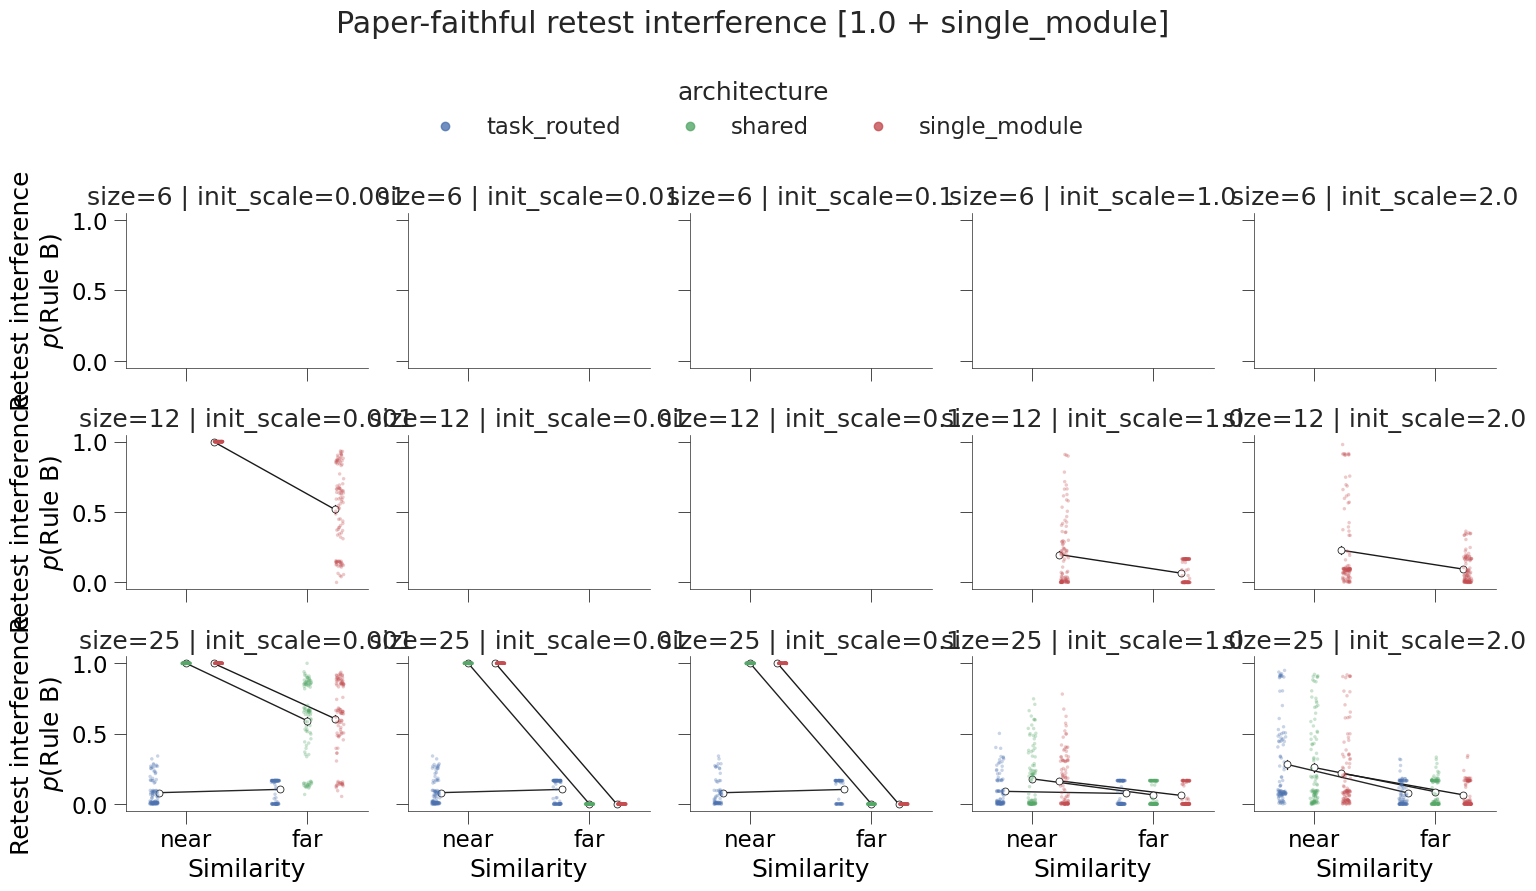

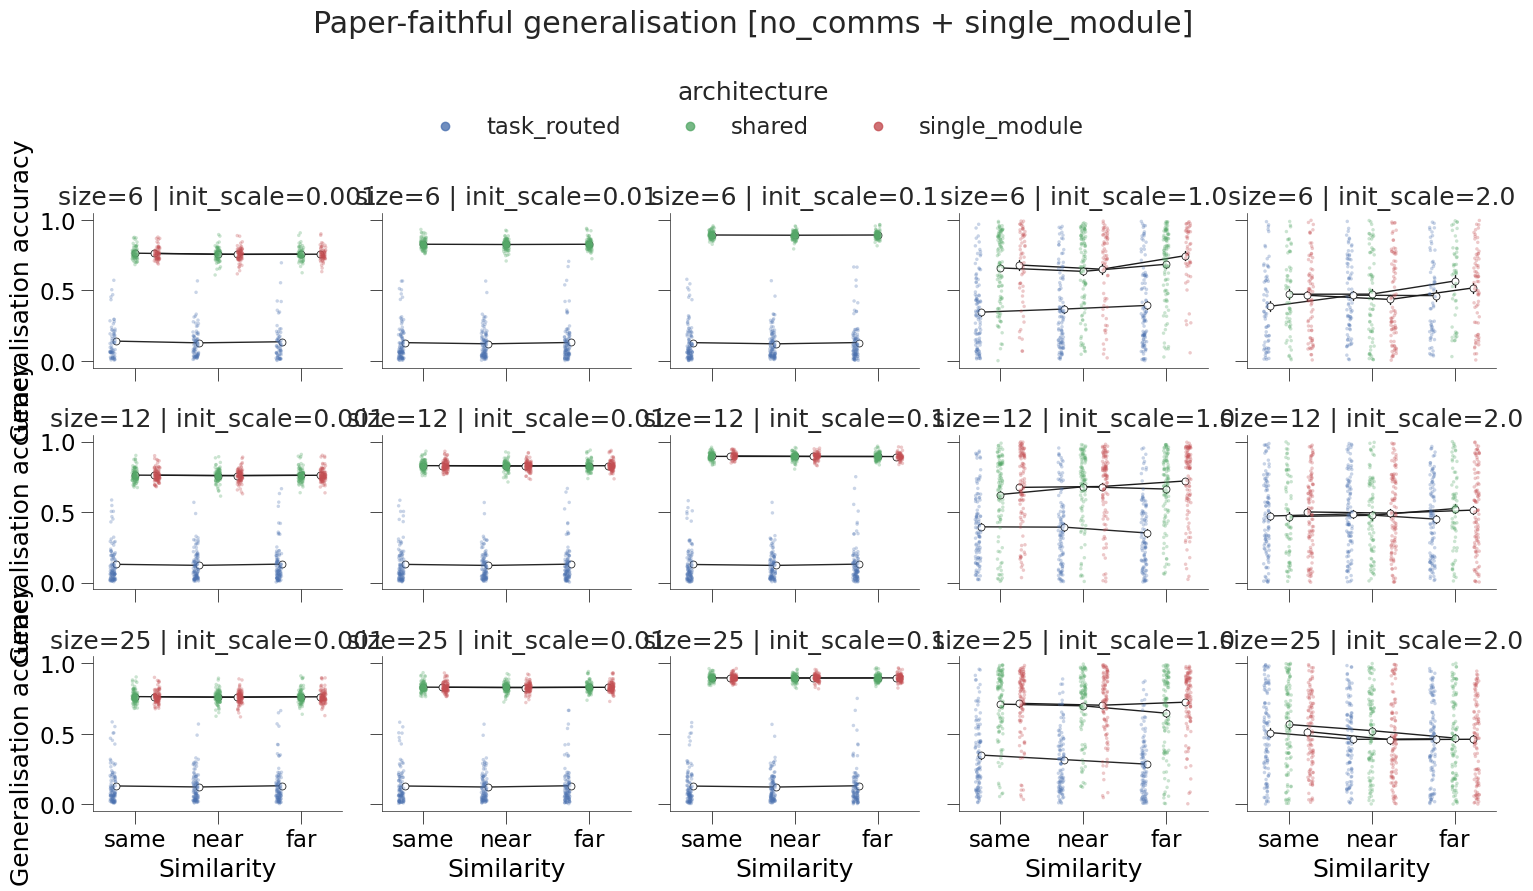

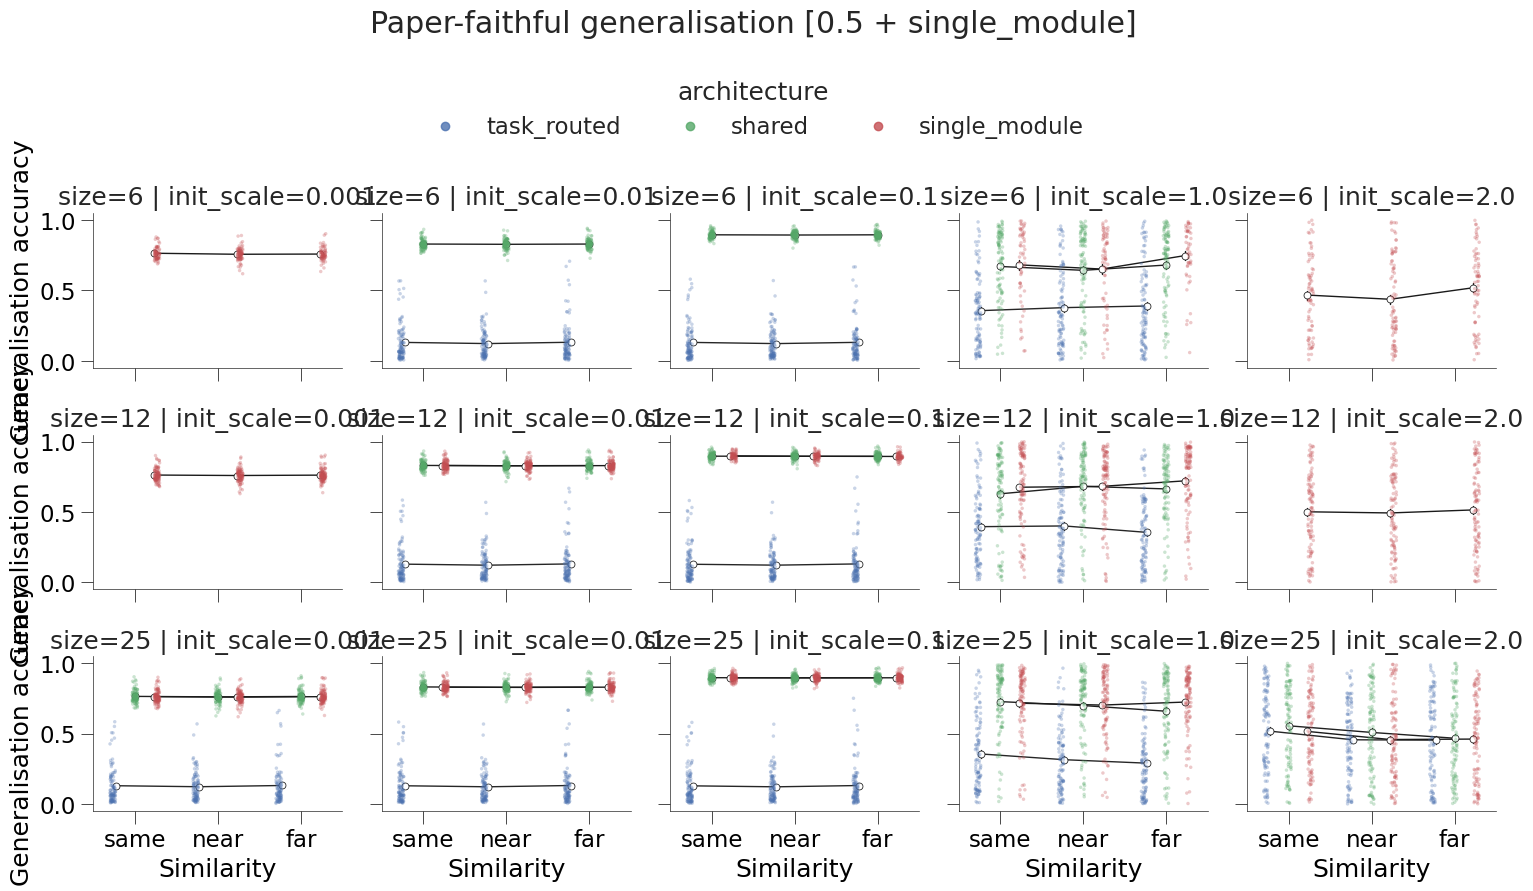

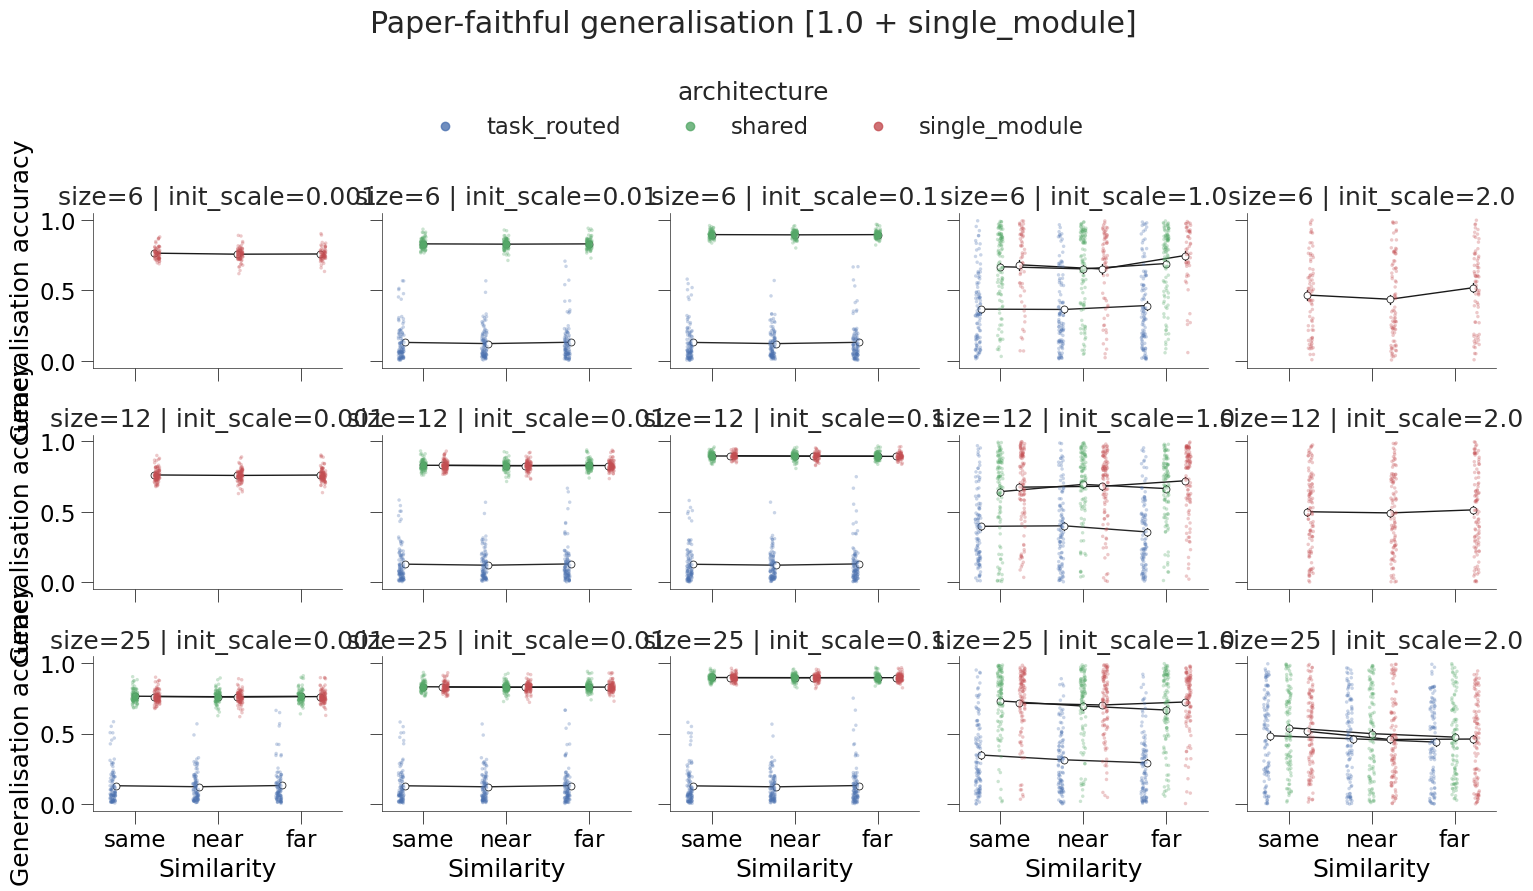

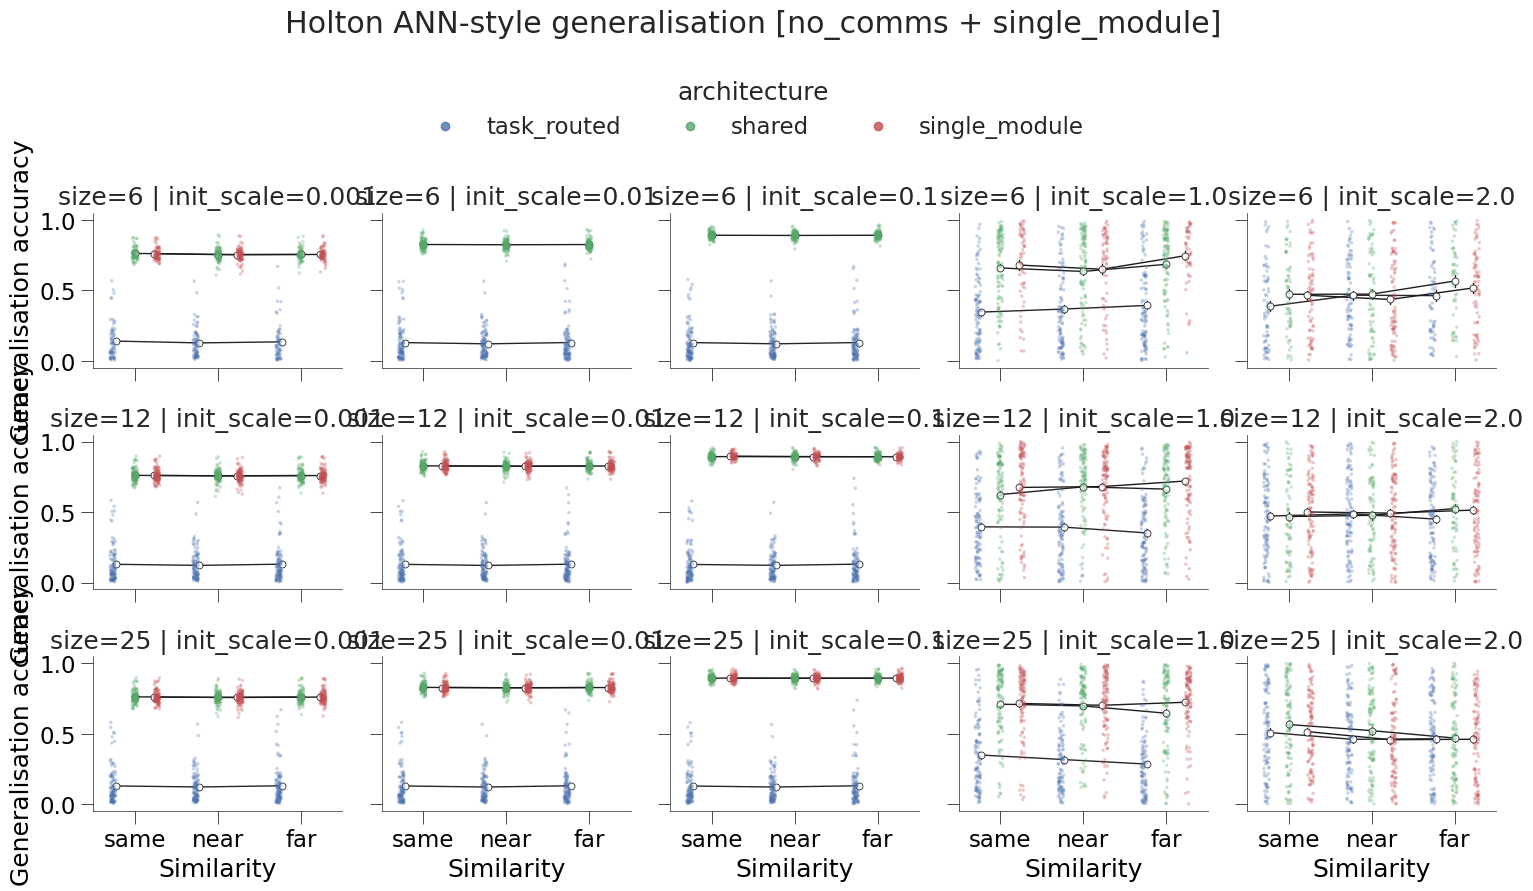

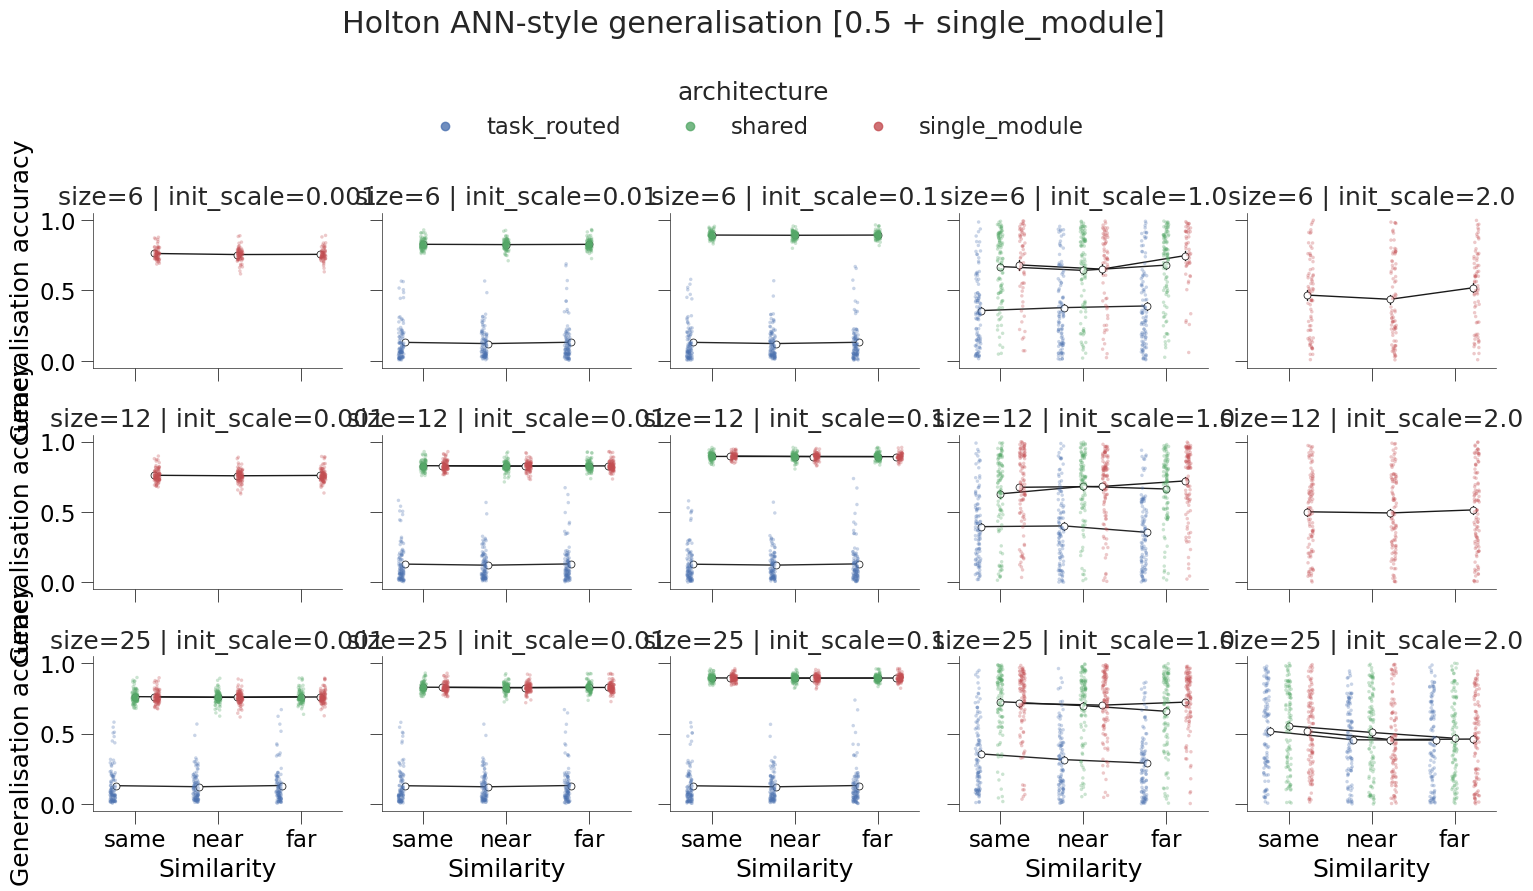

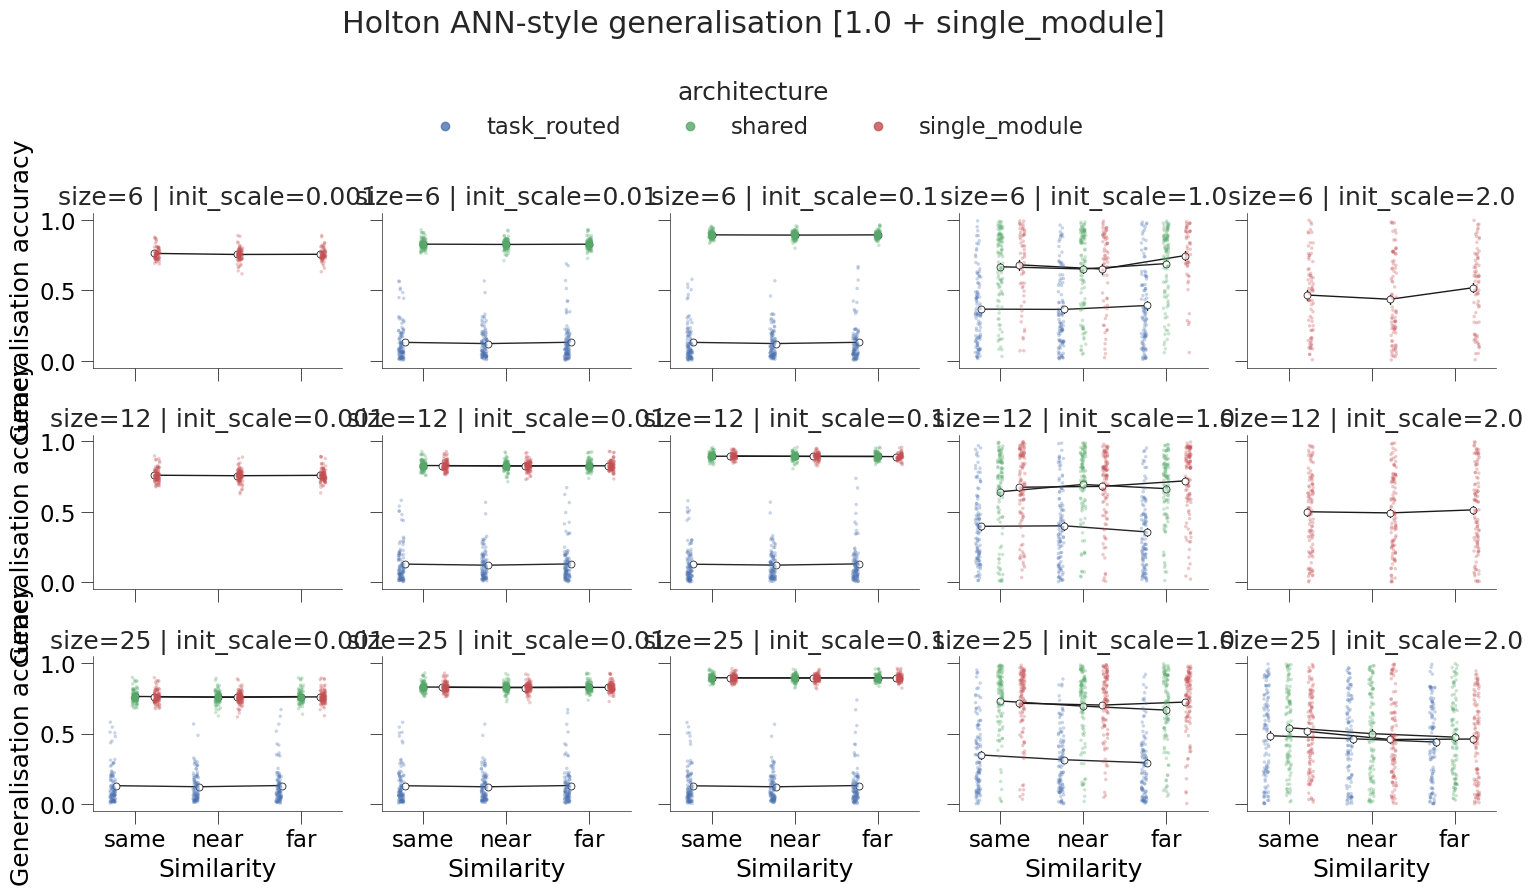

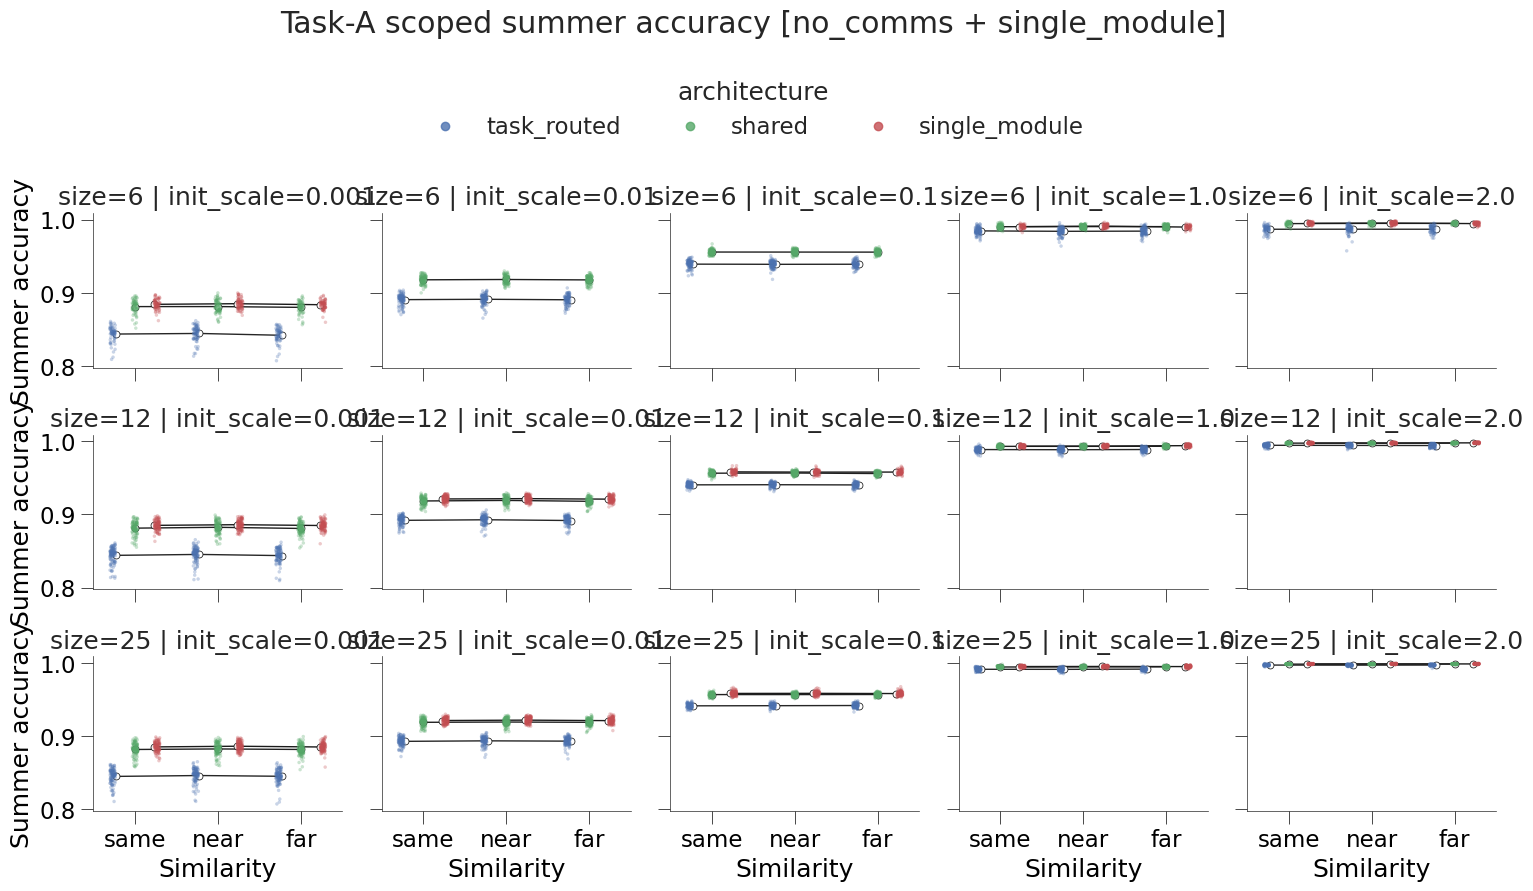

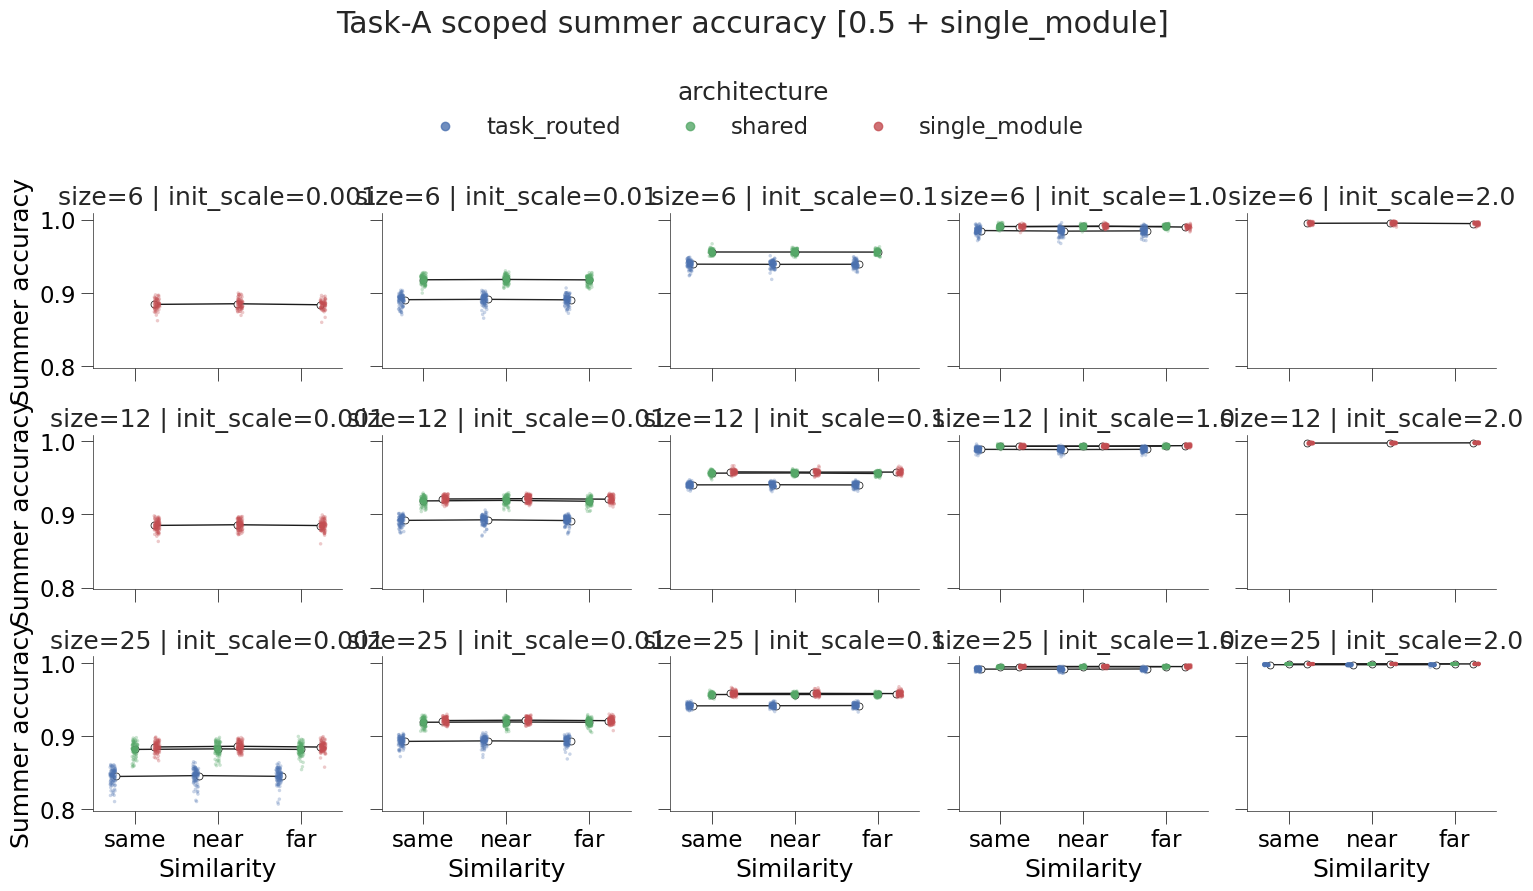

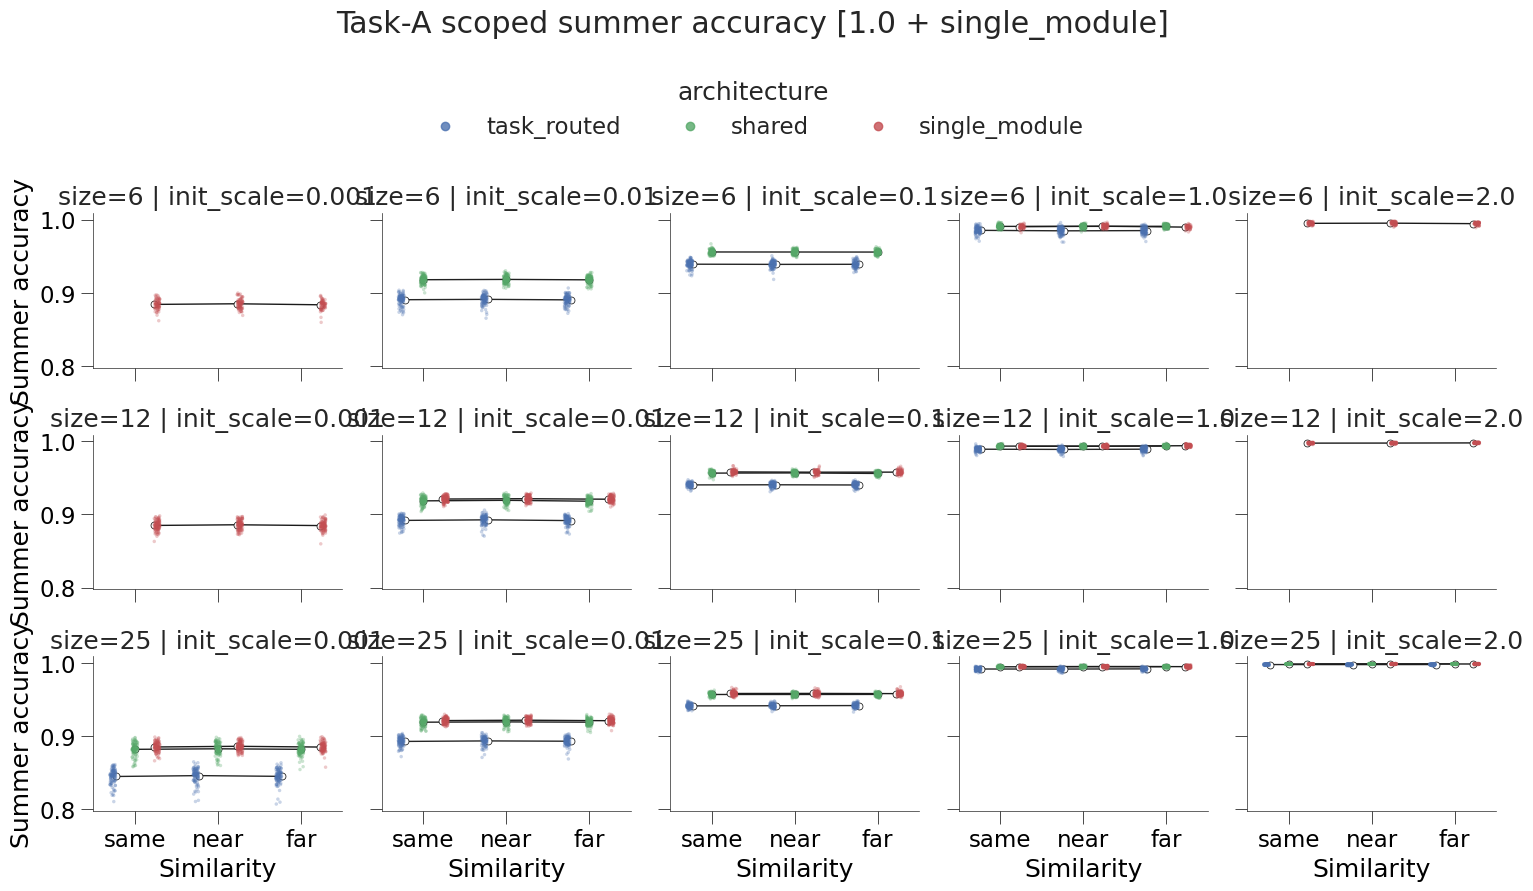

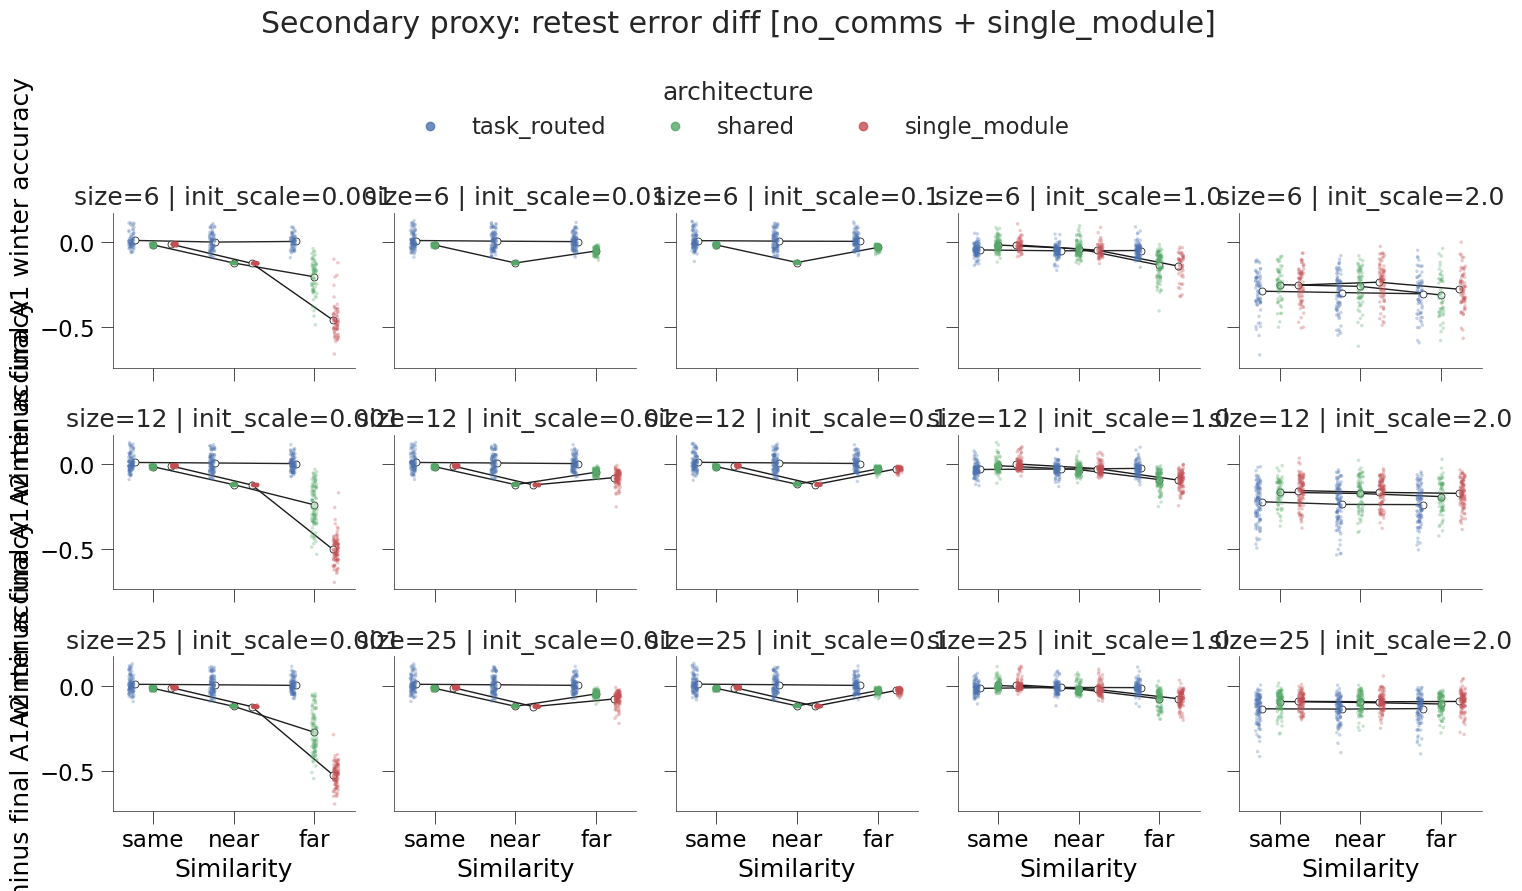

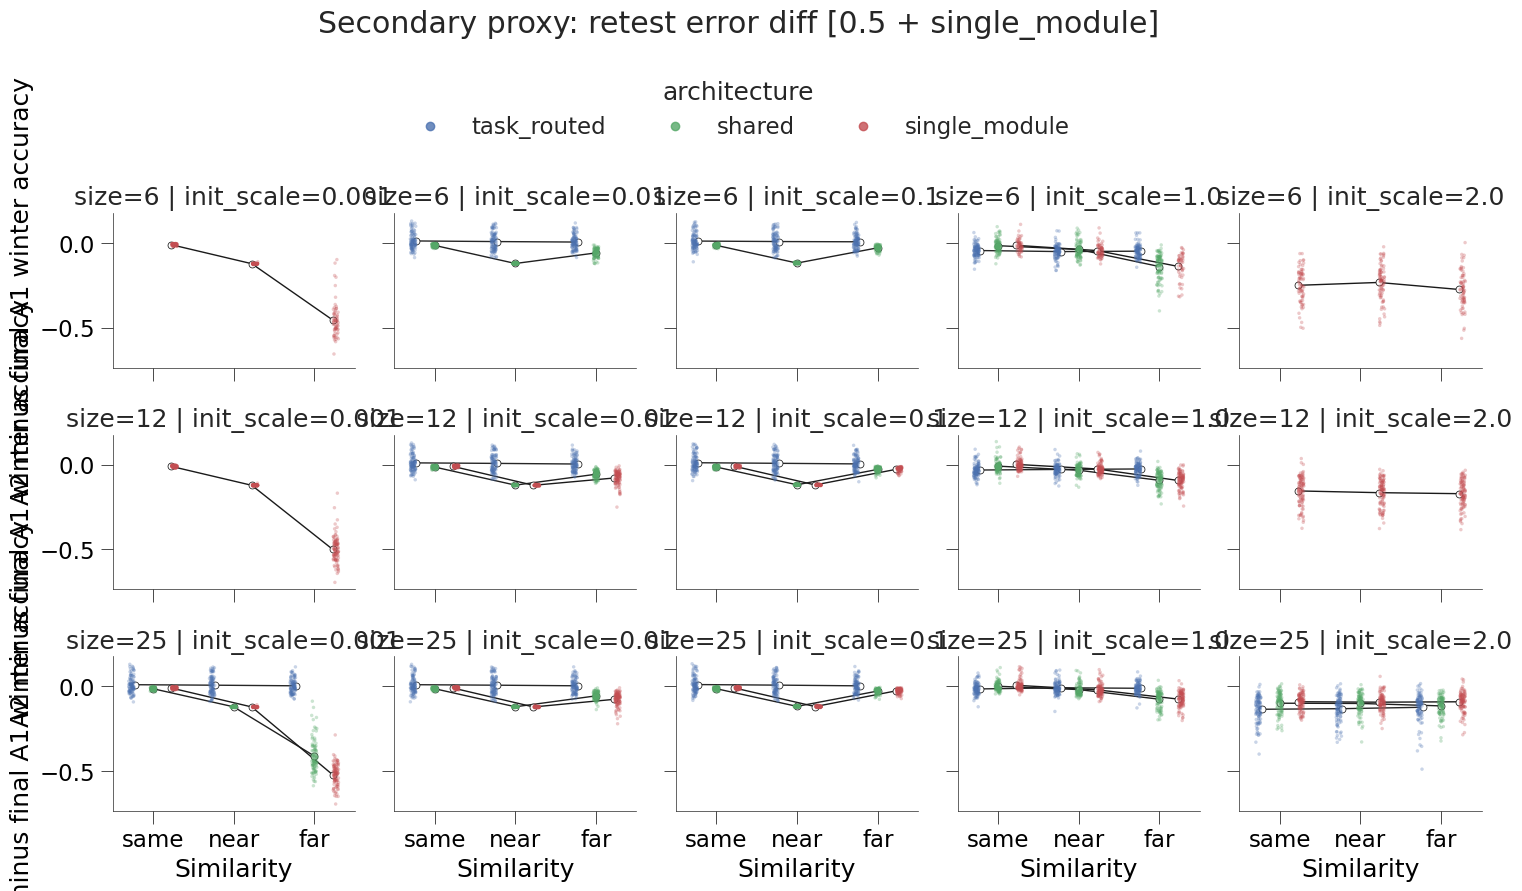

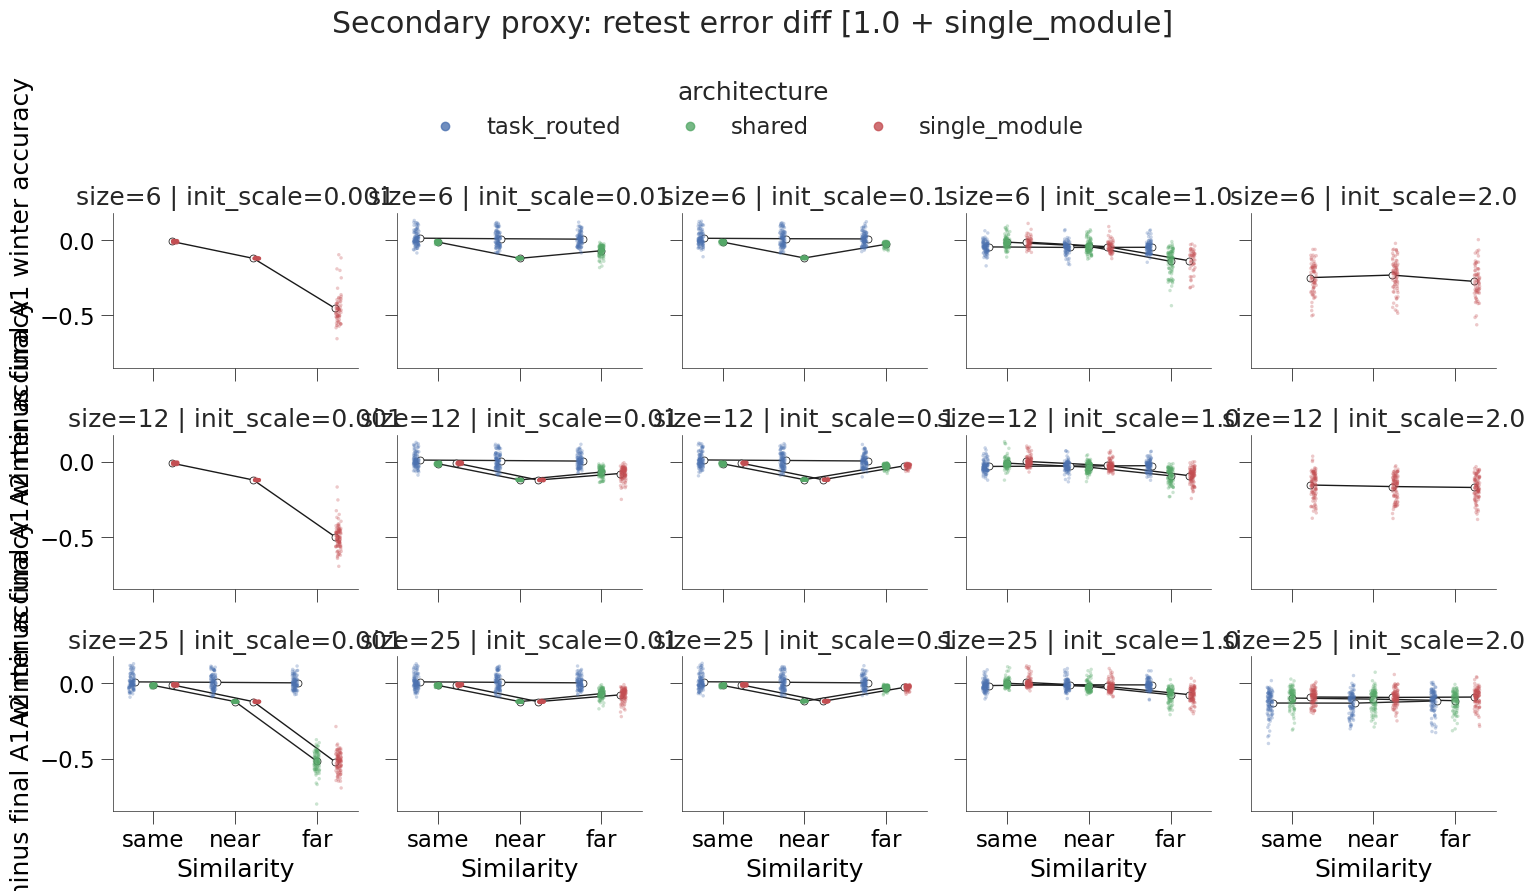

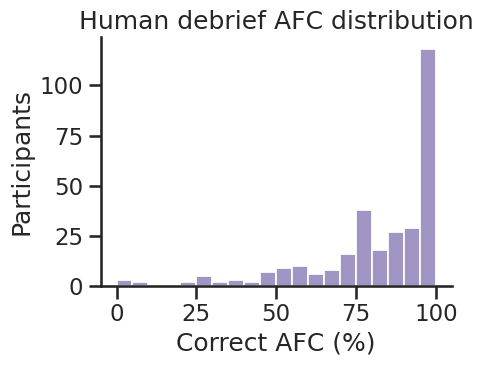

In [10]:
# Verification figures for primary and secondary metrics

sns.set_theme(style="ticks", context="talk")

routing_order = ["task_routed", "shared", "single_module"]
if "routing_palette" not in globals():
    routing_palette = {
        "task_routed": "#4C72B0",
        "shared": "#55A868",
        "single_module": "#C44E52",
    }


def _style_holton_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.5)
    ax.spines["bottom"].set_linewidth(0.5)
    ax.tick_params(colors="black", width=0.5)
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.grid(False)


def _plot_metric(metric_df, value_col, title, y_label, *, condition_order=None):
    if metric_df is None or metric_df.empty:
        print(f"No rows for {title}.")
        return
    base_df = metric_df.copy()
    if condition_order is not None and "condition" in base_df.columns:
        base_df = base_df[base_df["condition"].isin(condition_order)].copy()
        base_df["condition"] = pd.Categorical(base_df["condition"], categories=condition_order, ordered=True)
    base_df["routing"] = pd.Categorical(base_df["routing"], categories=routing_order, ordered=True)
    base_df["size"] = pd.Categorical(base_df["size"], categories=size_order, ordered=True)
    base_df["init_scale"] = base_df["init_scale"].astype(float)

    plot_sparsities = [sp for sp in sparsity_order if sp != "single_module"]
    for sparsity_label in plot_sparsities:
        plot_df = base_df[
            (base_df["sparsity_label"].astype(str) == sparsity_label)
            | (base_df["routing"].astype(str) == "single_module")
        ].copy()
        if plot_df.empty:
            continue
        g = sns.catplot(
            data=plot_df,
            x="condition",
            y=value_col,
            hue="routing",
            col="init_scale",
            row="size",
            kind="strip",
            dodge=True,
            jitter=True,
            order=condition_order,
            hue_order=routing_order,
            palette=routing_palette,
            size=2.5,
            linewidth=0,
            alpha=0.3,
            height=2.8,
            aspect=1.1,
            legend=False,
        )
        for ax_key, ax in g.axes_dict.items():
            if isinstance(ax_key, tuple):
                row_size, init_scale = ax_key
            else:
                row_size, init_scale = None, ax_key
            ax_df = plot_df.copy()
            if row_size is not None:
                ax_df = ax_df[ax_df["size"] == row_size]
            ax_df = ax_df[np.isclose(ax_df["init_scale"], float(init_scale))]
            if ax_df.empty:
                _style_holton_axes(ax)
                continue
            sns.pointplot(
                data=ax_df,
                x="condition",
                y=value_col,
                hue="routing",
                order=condition_order,
                hue_order=routing_order,
                dodge=0.45,
                palette="dark:k",
                markers="",
                errorbar="se",
                linestyles="-",
                linewidth=1,
                ax=ax,
                legend=False,
            )
            sns.pointplot(
                data=ax_df,
                x="condition",
                y=value_col,
                hue="routing",
                order=condition_order,
                hue_order=routing_order,
                dodge=0.45,
                palette=["k"] * len(routing_order),
                errorbar=None,
                markers="o",
                linestyles="",
                markersize=5,
                linewidth=0.75,
                ax=ax,
                legend=False,
                markerfacecolor="white",
                markeredgecolor="k",
            )
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()
            _style_holton_axes(ax)
        handles = [
            plt.Line2D(
                [0], [0],
                marker="o",
                linestyle="",
                markersize=6,
                markerfacecolor=colour,
                markeredgecolor=colour,
                alpha=0.8,
                label=label,
            )
            for label, colour in routing_palette.items()
            if label in routing_order and label in plot_df["routing"].astype(str).unique()
        ]
        if handles:
            g.fig.legend(
                handles=handles,
                labels=[h.get_label() for h in handles],
                title="architecture",
                loc="upper center",
                bbox_to_anchor=(0.5, 1.01),
                ncol=len(handles),
                frameon=False,
            )
        g.set_axis_labels("Similarity", y_label)
        g.set_titles(row_template="size={row_name}", col_template="init_scale={col_name}")
        g.fig.suptitle(f"{title} [{sparsity_label} + single_module]", y=1.07)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()


_plot_metric(
    transfer_df,
    "transfer_error_diff",
    "Paper-faithful transfer",
    "Transfer error diff",
    condition_order=["same", "near", "far"],
)

_plot_metric(
    interference_df,
    "interference",
    "Paper-faithful retest interference",
    "Retest interference\n$p$(Rule B)",
    condition_order=["near", "far"],
)

_plot_metric(
    generalisation_df,
    "generalisation_paper_faithful",
    "Paper-faithful generalisation",
    "Generalisation accuracy",
    condition_order=["same", "near", "far"],
)

_plot_metric(
    generalisation_df,
    "generalisation_holton_ann_style",
    "Holton ANN-style generalisation",
    "Generalisation accuracy",
    condition_order=["same", "near", "far"],
)

_plot_metric(
    secondary_ann_df,
    "summer_accuracy_taskA_scoped",
    "Task-A scoped summer accuracy",
    "Summer accuracy",
    condition_order=["same", "near", "far"],
)

_plot_metric(
    secondary_ann_df,
    "retest_error_diff",
    "Secondary proxy: retest error diff",
    "A2 minus final A1 winter accuracy",
    condition_order=["same", "near", "far"],
)

if not human_afc_df.empty:
    plt.figure(figsize=(5, 4))
    sns.histplot(data=human_afc_df, x="correct_afc", bins=20, color="#8172B2")
    plt.xlabel("Correct AFC (%)")
    plt.ylabel("Participants")
    plt.title("Human debrief AFC distribution")
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("No rows for human AFC plot.")


## Verification Checklist

Use this notebook to verify the paper-faithful standards before porting logic into presentation notebooks:

- Transfer uses **last 6 A1 winter** vs **first 6 B winter**.
- Interference uses von Mises **`1 - A_weight_A2`** and is restricted to **near/far**.
- Generalisation now shows both **paper-faithful late-A1** and **Holton ANN-style full-A1** variants.
- Summer accuracy now shows both **Task-A scoped** and **Holton ANN-style** variants.
- `correct_afc` is treated as a **human-only debrief metric** loaded from `trial_df.csv`.
- `retest_error_diff` is included only as a **secondary proxy metric**, not as an interference substitute.
- Coverage and missing-fit status are printed before figures.
- Participant counts and mask counts are visible for every metric across sizes `6`, `12`, and `25`.
- If a panel is empty, inspect the coverage table first and then the raw schema section.
